In [69]:
import pandas as pd
import numpy as np
from pathlib import Path


def find_csv_header_line(filepath, required_first_col="Time"):
    """
    Busca la línea donde empieza realmente la tabla CSV.
    
    Soporta:
    1) Archivos que empiezan directamente con:
       Time,col1,col2,...
       
    2) Archivos tipo SensorConnect:
       FILE_INFO
       ...
       DATA_START
       Time,col1,col2,...
    """
    filepath = Path(filepath)

    with filepath.open("r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    # Caso 1: buscar línea que empieza con Time,
    for i, line in enumerate(lines):
        clean = line.strip()

        if clean.startswith(required_first_col + ","):
            return i

    raise ValueError(
        f"No se encontró una línea de encabezado que empiece con '{required_first_col},'"
    )


def read_imu_csv(filepath):
    """
    Lee un CSV de IMU de forma genérica.
    Convierte columnas numéricas.
    Crea tiempo relativo.
    Calcula dt.
    Ordena por Time.
    """
    header_line = find_csv_header_line(filepath, required_first_col="Time")

    df = pd.read_csv(
        filepath,
        skiprows=header_line,
        sep=",",
        skipinitialspace=True
    )

    # Limpiar nombres de columnas
    df.columns = [c.strip() for c in df.columns]

    # Convertir todo lo posible a número
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # Eliminar filas vacías o inválidas
    df = df.dropna(subset=["Time"]).reset_index(drop=True)

    # Ordenar por tiempo
    df = df.sort_values("Time").reset_index(drop=True)

    # Time parece estar en nanosegundos Unix
    df["t_s"] = (df["Time"] - df["Time"].iloc[0]) * 1e-9

    # dt en segundos
    df["dt"] = df["t_s"].diff()

    # Para la primera fila puedes usar el dt mediano
    dt_median = df["dt"].median()
    df.loc[0, "dt"] = dt_median

    return df

In [70]:
df = read_imu_csv("SensorConnectData__1.csv")

print(df.head())
print(df.columns)
print(df[["Time", "t_s", "dt"]].head())

                  Time  reference_time  gps_timestamp  deltaVelX  deltaVelY  \
0  1776867651109628141   1203943000000       1203.948   0.000150   0.000096   
1  1776867651129055331   1203963000000       1203.968   0.000153   0.000095   
2  1776867651148775540   1203983000000       1203.988   0.000153   0.000097   
3  1776867651158459255   1204003000000       1204.008   0.000150   0.000095   
4  1776867651168547547   1204003000000       1204.008   0.000150   0.000095   

   deltaVelZ  deltaThetaX  deltaThetaY  deltaThetaZ  estLinearAccelX  ...  \
0  -0.009959     0.000003    -0.000001     0.000001         0.122194  ...   
1  -0.009962     0.000000    -0.000005     0.000003         0.036777  ...   
2  -0.009964     0.000002     0.000001     0.000002         0.010446  ...   
3  -0.009956     0.000003     0.000001    -0.000002         0.002468  ...   
4  -0.009956     0.000003     0.000001    -0.000002         0.002468  ...   

   scaledGyroZ  scaledMagX  scaledMagY  scaledMagZ  estGyroBia

In [71]:
def add_imu_aliases(df):
    """
    Agrega columnas con nombres cortos útiles para INS.
    No elimina las columnas originales.
    """

    alias_map = {
        # delta velocidad
        "deltaVelX": "dvx",
        "deltaVelY": "dvy",
        "deltaVelZ": "dvz",

        # delta theta
        "deltaThetaX": "dthx",
        "deltaThetaY": "dthy",
        "deltaThetaZ": "dthz",

        # aceleración lineal estimada por el AHRS
        "estLinearAccelX": "alx",
        "estLinearAccelY": "aly",
        "estLinearAccelZ": "alz",

        # velocidad angular estimada
        "estAngularRateX": "wx",
        "estAngularRateY": "wy",
        "estAngularRateZ": "wz",

        # acelerómetro crudo/escalado
        "scaledAccelX": "ax",
        "scaledAccelY": "ay",
        "scaledAccelZ": "az",

        # giroscopio crudo/escalado
        "scaledGyroX": "gx",
        "scaledGyroY": "gy",
        "scaledGyroZ": "gz",

        # magnetómetro
        "scaledMagX": "mx",
        "scaledMagY": "my",
        "scaledMagZ": "mz",

        # bias estimado del gyro
        "estGyroBiasX": "bgx",
        "estGyroBiasY": "bgy",
        "estGyroBiasZ": "bgz",
    }

    df = df.copy()

    for original, short in alias_map.items():
        if original in df.columns:
            df[short] = df[original]

    return df

In [72]:
df = read_imu_csv("SensorConnectData__1.csv")
df = add_imu_aliases(df)

print(df[["t_s", "dt", "dvx", "dvy", "dvz", "dthx", "dthy", "dthz"]].head())

        t_s        dt       dvx       dvy       dvz      dthx      dthy  \
0  0.000000  0.010155  0.000150  0.000096 -0.009959  0.000003 -0.000001   
1  0.019427  0.019427  0.000153  0.000095 -0.009962  0.000000 -0.000005   
2  0.039147  0.019720  0.000153  0.000097 -0.009964  0.000002  0.000001   
3  0.048831  0.009684  0.000150  0.000095 -0.009956  0.000003  0.000001   
4  0.058919  0.010088  0.000150  0.000095 -0.009956  0.000003  0.000001   

       dthz  
0  0.000001  
1  0.000003  
2  0.000002  
3 -0.000002  
4 -0.000002  


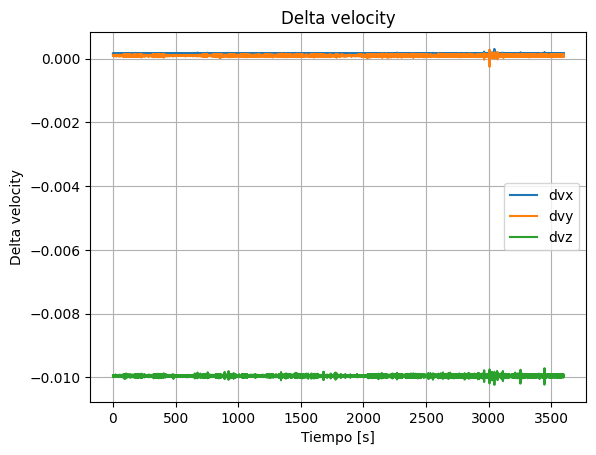

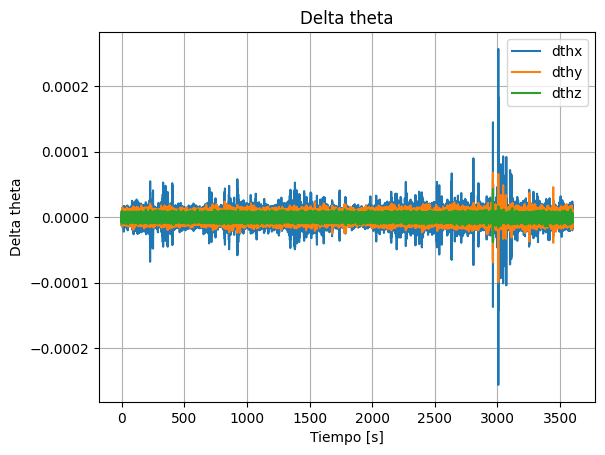

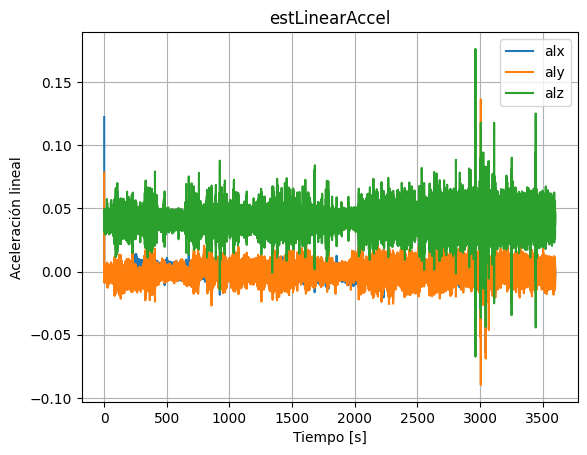

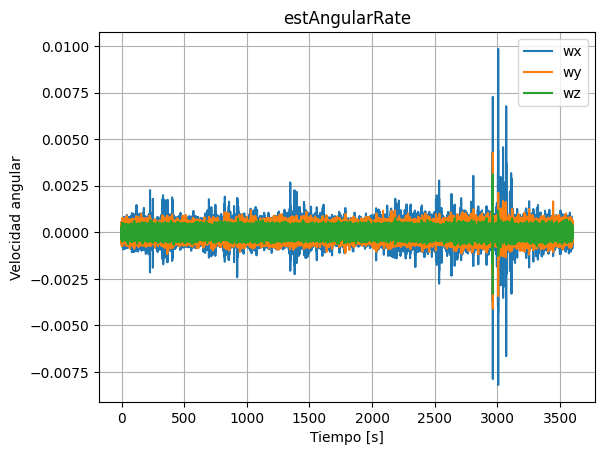

In [73]:
import matplotlib.pyplot as plt


def plot_imu_basic(df):
    t = df["t_s"]

    plt.figure()
    plt.plot(t, df["dvx"], label="dvx")
    plt.plot(t, df["dvy"], label="dvy")
    plt.plot(t, df["dvz"], label="dvz")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Delta velocity")
    plt.title("Delta velocity")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(t, df["dthx"], label="dthx")
    plt.plot(t, df["dthy"], label="dthy")
    plt.plot(t, df["dthz"], label="dthz")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Delta theta")
    plt.title("Delta theta")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(t, df["alx"], label="alx")
    plt.plot(t, df["aly"], label="aly")
    plt.plot(t, df["alz"], label="alz")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Aceleración lineal")
    plt.title("estLinearAccel")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure()
    plt.plot(t, df["wx"], label="wx")
    plt.plot(t, df["wy"], label="wy")
    plt.plot(t, df["wz"], label="wz")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Velocidad angular")
    plt.title("estAngularRate")
    plt.grid(True)
    plt.legend()
    plt.show()


plot_imu_basic(df)

In [74]:
def read_imu_file(filepath):
    df = read_imu_csv(filepath)
    df = add_imu_aliases(df)

    return df

In [75]:
df = read_imu_file("SensorConnectData__1.csv")

t = df["t_s"].to_numpy()
dt = df["dt"].to_numpy()

delta_v = df[["dvx", "dvy", "dvz"]].to_numpy()
delta_theta = df[["dthx", "dthy", "dthz"]].to_numpy()

a_lin = df[["alx", "aly", "alz"]].to_numpy()
w = df[["wx", "wy", "wz"]].to_numpy()

In [76]:
df

,Time,reference_time,gps_timestamp,deltaVelX,deltaVelY,deltaVelZ,deltaThetaX,deltaThetaY,deltaThetaZ,estLinearAccelX,...,az,gx,gy,gz,mx,my,mz,bgx,bgy,bgz
0,1776867651109628141,1203943000000,1203.948,0.000150,0.000096,-0.009959,0.000003,-0.000001,0.000001,0.122194,...,-0.995762,0.000178,-0.000260,0.000160,-0.437102,0.088032,0.137968,0.000000,0.000000,0.000000
1,1776867651129055331,1203963000000,1203.968,0.000153,0.000095,-0.009962,0.000000,-0.000005,0.000003,0.036777,...,-0.996081,0.000256,-0.000400,0.000118,-0.437223,0.088609,0.138281,0.000000,0.000000,0.000000
2,1776867651148775540,1203983000000,1203.988,0.000153,0.000097,-0.009964,0.000002,0.000001,0.000002,0.010446,...,-0.996118,0.000254,0.000011,0.000094,-0.437777,0.088929,0.138883,0.000000,0.000000,0.000000
3,1776867651158459255,1204003000000,1204.008,0.000150,0.000095,-0.009956,0.000003,0.000001,-0.000002,0.002468,...,-0.995645,0.000149,0.000314,-0.000076,-0.437949,0.088658,0.138523,0.000000,0.000000,-0.000000
4,1776867651168547547,1204003000000,1204.008,0.000150,0.000095,-0.009956,0.000003,0.000001,-0.000002,0.002468,...,-0.995645,0.000149,0.000314,-0.000076,-0.437949,0.088658,0.138523,0.000000,0.000000,-0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293748,1776871251058017354,4803893000000,4803.893,0.000148,0.000085,-0.009922,-0.000006,0.000004,-0.000001,-0.002777,...,-0.994317,-0.000248,0.000114,-0.000212,-0.437231,0.088018,0.139277,0.000025,-0.000028,-0.000054
293749,1776871251077746367,4803913000000,4803.913,0.000152,0.000104,-0.009959,0.000003,0.000006,0.000002,-0.003580,...,-0.995346,0.000269,0.000270,0.000038,-0.437083,0.087613,0.138715,0.000025,-0.000028,-0.000054
293750,1776871251087383122,4803923000000,4803.928,0.000147,0.000089,-0.009957,0.000010,0.000010,0.000003,-0.002733,...,-0.995560,0.000531,0.000624,0.000140,-0.436761,0.088652,0.139512,0.000025,-0.000028,-0.000054
293751,1776871251097535211,4803923000000,4803.928,0.000147,0.000089,-0.009957,0.000010,0.000010,0.000003,-0.002733,...,-0.995560,0.000531,0.000624,0.000140,-0.436761,0.088652,0.139512,0.000025,-0.000028,-0.000054


In [77]:
import pandas as pd
import numpy as np
from pathlib import Path


def find_csv_header_line(filepath, required_first_col="Time"):
    filepath = Path(filepath)

    with filepath.open("r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        clean = line.strip()

        if clean.startswith(required_first_col + ","):
            return i

    raise ValueError(
        f"No se encontró una línea de encabezado que empiece con '{required_first_col},'"
    )


def read_generic_sensor_csv(filepath):
    """
    Lee archivos CSV que empiezan directamente con Time,...
    o archivos SensorConnect con DATA_START antes de la tabla.
    """
    header_line = find_csv_header_line(filepath, required_first_col="Time")

    df = pd.read_csv(
        filepath,
        skiprows=header_line,
        sep=",",
        skipinitialspace=True
    )

    df.columns = [c.strip() for c in df.columns]

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["Time"]).copy()
    df = df.sort_values("Time").reset_index(drop=True)

    return df

In [78]:
df_imu = read_generic_sensor_csv("SensorConnectData__1.csv")

print(df_imu.head())
print(df_imu.columns)

                  Time  reference_time  gps_timestamp  deltaVelX  deltaVelY  \
0  1776867651109628141   1203943000000       1203.948   0.000150   0.000096   
1  1776867651129055331   1203963000000       1203.968   0.000153   0.000095   
2  1776867651148775540   1203983000000       1203.988   0.000153   0.000097   
3  1776867651158459255   1204003000000       1204.008   0.000150   0.000095   
4  1776867651168547547   1204003000000       1204.008   0.000150   0.000095   

   deltaVelZ  deltaThetaX  deltaThetaY  deltaThetaZ  estLinearAccelX  ...  \
0  -0.009959     0.000003    -0.000001     0.000001         0.122194  ...   
1  -0.009962     0.000000    -0.000005     0.000003         0.036777  ...   
2  -0.009964     0.000002     0.000001     0.000002         0.010446  ...   
3  -0.009956     0.000003     0.000001    -0.000002         0.002468  ...   
4  -0.009956     0.000003     0.000001    -0.000002         0.002468  ...   

   scaledGyroX  scaledGyroY  scaledGyroZ  scaledMagX  scaledMa

In [79]:
df_q = read_generic_sensor_csv("QuaternionEst__1.csv")

print(df_q.head())
print(df_q.columns)

                  Time  reference_time  gps_timestamp  \
0  1776867651109628141   1203943000000       1203.948   
1  1776867651129055331   1203963000000       1203.968   
2  1776867651148775540   1203983000000       1203.988   
3  1776867651158459255   1204003000000       1204.008   
4  1776867651168547547   1204003000000       1204.008   

   estOrientQuaternion[0-0]  estOrientQuaternion[0-1]  \
0                  0.999960                 -0.004786   
1                  0.999960                 -0.004783   
2                  0.999960                 -0.004781   
3                  0.999961                 -0.004752   
4                  0.999961                 -0.004752   

   estOrientQuaternion[0-2]  estOrientQuaternion[0-3]  \
0                  0.007499                  0.000036   
1                  0.007495                  0.000036   
2                  0.007497                  0.000036   
3                  0.007509                  0.000035   
4                  0.007509  

In [80]:
def add_imu_aliases(df):
    """
    Agrega nombres cortos para las señales principales.
    """

    alias_map = {
        "deltaVelX": "dvx",
        "deltaVelY": "dvy",
        "deltaVelZ": "dvz",

        "deltaThetaX": "dthx",
        "deltaThetaY": "dthy",
        "deltaThetaZ": "dthz",

        "estLinearAccelX": "alx",
        "estLinearAccelY": "aly",
        "estLinearAccelZ": "alz",

        "estAngularRateX": "wx",
        "estAngularRateY": "wy",
        "estAngularRateZ": "wz",

        "scaledAccelX": "ax",
        "scaledAccelY": "ay",
        "scaledAccelZ": "az",

        "scaledGyroX": "gx",
        "scaledGyroY": "gy",
        "scaledGyroZ": "gz",

        "scaledMagX": "mx",
        "scaledMagY": "my",
        "scaledMagZ": "mz",

        "estGyroBiasX": "bgx",
        "estGyroBiasY": "bgy",
        "estGyroBiasZ": "bgz",
    }

    df = df.copy()

    for original, short in alias_map.items():
        if original in df.columns:
            df[short] = df[original]

    return df

In [81]:
df_q = read_generic_sensor_csv("QuaternionEst__1.csv")
df_q = add_imu_aliases(df_q)
print(df_q.head())
print(df_q.columns)

                  Time  reference_time  gps_timestamp  \
0  1776867651109628141   1203943000000       1203.948   
1  1776867651129055331   1203963000000       1203.968   
2  1776867651148775540   1203983000000       1203.988   
3  1776867651158459255   1204003000000       1204.008   
4  1776867651168547547   1204003000000       1204.008   

   estOrientQuaternion[0-0]  estOrientQuaternion[0-1]  \
0                  0.999960                 -0.004786   
1                  0.999960                 -0.004783   
2                  0.999960                 -0.004781   
3                  0.999961                 -0.004752   
4                  0.999961                 -0.004752   

   estOrientQuaternion[0-2]  estOrientQuaternion[0-3]  \
0                  0.007499                  0.000036   
1                  0.007495                  0.000036   
2                  0.007497                  0.000036   
3                  0.007509                  0.000035   
4                  0.007509  

In [82]:
def rename_quaternion_columns(df_q):
    df_q = df_q.copy()

    rename_map = {
        "estOrientQuaternion[0-0]": "q0",
        "estOrientQuaternion[0-1]": "q1",
        "estOrientQuaternion[0-2]": "q2",
        "estOrientQuaternion[0-3]": "q3",
        "estOrientQuaternion:valid": "qValid",
    }

    df_q = df_q.rename(columns=rename_map)

    return df_q

In [83]:
df_q = rename_quaternion_columns(df_q)

print(df_q[["Time", "q0", "q1", "q2", "q3", "qValid"]].head())

                  Time        q0        q1        q2        q3  qValid
0  1776867651109628141  0.999960 -0.004786  0.007499  0.000036       1
1  1776867651129055331  0.999960 -0.004783  0.007495  0.000036       1
2  1776867651148775540  0.999960 -0.004781  0.007497  0.000036       1
3  1776867651158459255  0.999961 -0.004752  0.007509  0.000035       1
4  1776867651168547547  0.999961 -0.004752  0.007509  0.000035       1


In [84]:
df = pd.merge(
    df_imu,
    df_q[["Time", "q0", "q1", "q2", "q3", "qValid"]],
    on="Time",
    how="left"
)

In [85]:
df

,Time,reference_time,gps_timestamp,deltaVelX,deltaVelY,deltaVelZ,deltaThetaX,deltaThetaY,deltaThetaZ,estLinearAccelX,...,scaledMagZ,estGyroBiasX,estGyroBiasY,estGyroBiasZ,estGyroBias:valid,q0,q1,q2,q3,qValid
0,1776867651109628141,1203943000000,1203.948,0.000150,0.000096,-0.009959,0.000003,-0.000001,0.000001,0.122194,...,0.137968,0.000000,0.000000,0.000000,1,0.999960,-0.004786,0.007499,0.000036,1
1,1776867651129055331,1203963000000,1203.968,0.000153,0.000095,-0.009962,0.000000,-0.000005,0.000003,0.036777,...,0.138281,0.000000,0.000000,0.000000,1,0.999960,-0.004783,0.007495,0.000036,1
2,1776867651148775540,1203983000000,1203.988,0.000153,0.000097,-0.009964,0.000002,0.000001,0.000002,0.010446,...,0.138883,0.000000,0.000000,0.000000,1,0.999960,-0.004781,0.007497,0.000036,1
3,1776867651158459255,1204003000000,1204.008,0.000150,0.000095,-0.009956,0.000003,0.000001,-0.000002,0.002468,...,0.138523,0.000000,0.000000,-0.000000,1,0.999961,-0.004752,0.007509,0.000035,1
4,1776867651168547547,1204003000000,1204.008,0.000150,0.000095,-0.009956,0.000003,0.000001,-0.000002,0.002468,...,0.138523,0.000000,0.000000,-0.000000,1,0.999961,-0.004752,0.007509,0.000035,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293748,1776871251058017354,4803893000000,4803.893,0.000148,0.000085,-0.009922,-0.000006,0.000004,-0.000001,-0.002777,...,0.139277,0.000025,-0.000028,-0.000054,1,0.999852,-0.004761,0.007711,-0.014654,1
293749,1776871251077746367,4803913000000,4803.913,0.000152,0.000104,-0.009959,0.000003,0.000006,0.000002,-0.003580,...,0.138715,0.000025,-0.000028,-0.000054,1,0.999852,-0.004759,0.007711,-0.014655,1
293750,1776871251087383122,4803923000000,4803.928,0.000147,0.000089,-0.009957,0.000010,0.000010,0.000003,-0.002733,...,0.139512,0.000025,-0.000028,-0.000054,1,0.999852,-0.004753,0.007719,-0.014652,1
293751,1776871251097535211,4803923000000,4803.928,0.000147,0.000089,-0.009957,0.000010,0.000010,0.000003,-0.002733,...,0.139512,0.000025,-0.000028,-0.000054,1,0.999852,-0.004753,0.007719,-0.014652,1


In [86]:
import pandas as pd
import numpy as np
from pathlib import Path


def find_csv_header_line(filepath, required_first_col="Time"):
    filepath = Path(filepath)

    with filepath.open("r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        clean = line.strip()

        if clean.startswith(required_first_col + ","):
            return i

    raise ValueError(
        f"No se encontró una línea de encabezado que empiece con '{required_first_col},'"
    )


def read_generic_sensor_csv(filepath):
    header_line = find_csv_header_line(filepath, required_first_col="Time")

    df = pd.read_csv(
        filepath,
        skiprows=header_line,
        sep=",",
        skipinitialspace=True
    )

    df.columns = [c.strip() for c in df.columns]

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["Time"]).copy()
    df = df.sort_values("Time").reset_index(drop=True)

    return df


def add_imu_aliases(df):
    """
    Agrega nombres cortos para las señales principales.
    """

    alias_map = {
        "deltaVelX": "dvx",
        "deltaVelY": "dvy",
        "deltaVelZ": "dvz",

        "deltaThetaX": "dthx",
        "deltaThetaY": "dthy",
        "deltaThetaZ": "dthz",

        "estLinearAccelX": "alx",
        "estLinearAccelY": "aly",
        "estLinearAccelZ": "alz",

        "estAngularRateX": "wx",
        "estAngularRateY": "wy",
        "estAngularRateZ": "wz",

        "scaledAccelX": "ax",
        "scaledAccelY": "ay",
        "scaledAccelZ": "az",

        "scaledGyroX": "gx",
        "scaledGyroY": "gy",
        "scaledGyroZ": "gz",

        "scaledMagX": "mx",
        "scaledMagY": "my",
        "scaledMagZ": "mz",

        "estGyroBiasX": "bgx",
        "estGyroBiasY": "bgy",
        "estGyroBiasZ": "bgz",
    }

    df = df.copy()

    for original, short in alias_map.items():
        if original in df.columns:
            df[short] = df[original]

    return df


def rename_quaternion_columns(df_q):
    """
    Renombra columnas de orientación a q0, q1, q2, q3.
    
    Según tu archivo:
    q0 = estOrientQuaternion[0-0]
    q1 = estOrientQuaternion[0-1]
    q2 = estOrientQuaternion[0-2]
    q3 = estOrientQuaternion[0-3]
    """

    rename_map = {
        "estOrientQuaternion[0-0]": "q0",
        "estOrientQuaternion[0-1]": "q1",
        "estOrientQuaternion[0-2]": "q2",
        "estOrientQuaternion[0-3]": "q3",
        "estOrientQuaternion:valid": "qValid",
    }

    df_q = df_q.rename(columns=rename_map)

    return df_q


def add_time_columns(df):
    """
    Agrega tiempo relativo en segundos y dt.
    Asume Time en nanosegundos Unix.
    """

    df = df.copy()
    df = df.sort_values("Time").reset_index(drop=True)

    df["t_s"] = (df["Time"] - df["Time"].iloc[0]) * 1e-9
    df["dt"] = df["t_s"].diff()

    dt_median = df["dt"].median()
    df.loc[0, "dt"] = dt_median

    return df


def read_and_merge_imu_quaternion(
    imu_file,
    quat_file,
    tolerance_ns=5_000_000
):
    """
    Lee archivo principal IMU y archivo de cuaterniones.
    Une ambos usando Time en nanosegundos Unix.

    tolerance_ns:
        1_000_000  = 1 ms
        5_000_000  = 5 ms
        10_000_000 = 10 ms
    """

    # Leer IMU principal
    df_imu = read_generic_sensor_csv(imu_file)
    df_imu = add_imu_aliases(df_imu)

    # Leer cuaterniones
    df_q = read_generic_sensor_csv(quat_file)
    df_q = rename_quaternion_columns(df_q)

    required_q_cols = ["Time", "q0", "q1", "q2", "q3", "qValid"]
    missing = [c for c in required_q_cols if c not in df_q.columns]

    if missing:
        raise ValueError(f"Faltan columnas de cuaternión: {missing}")

    # Ordenar antes de merge_asof
    df_imu = df_imu.sort_values("Time").reset_index(drop=True)
    df_q = df_q.sort_values("Time").reset_index(drop=True)

    # Unir por timestamp más cercano
    df = pd.merge_asof(
        df_imu,
        df_q[required_q_cols],
        on="Time",
        direction="nearest",
        tolerance=tolerance_ns
    )

    # Agregar t_s y dt
    df = add_time_columns(df)

    return df

In [87]:
df = read_and_merge_imu_quaternion(
    imu_file="SensorConnectData__1.csv",
    quat_file="QuaternionEst__1.csv",
    tolerance_ns=5_000_000
)

print(df.head())
print(df.columns)

print(df[[
    "Time", "t_s", "dt",
    "q0", "q1", "q2", "q3", "qValid",
    "dvx", "dvy", "dvz",
    "dthx", "dthy", "dthz",
    "alx", "aly", "alz",
    "wx", "wy", "wz"
]].head())

                  Time  reference_time  gps_timestamp  deltaVelX  deltaVelY  \
0  1776867651109628141   1203943000000       1203.948   0.000150   0.000096   
1  1776867651129055331   1203963000000       1203.968   0.000153   0.000095   
2  1776867651148775540   1203983000000       1203.988   0.000153   0.000097   
3  1776867651158459255   1204003000000       1204.008   0.000150   0.000095   
4  1776867651168547547   1204003000000       1204.008   0.000150   0.000095   

   deltaVelZ  deltaThetaX  deltaThetaY  deltaThetaZ  estLinearAccelX  ...  \
0  -0.009959     0.000003    -0.000001     0.000001         0.122194  ...   
1  -0.009962     0.000000    -0.000005     0.000003         0.036777  ...   
2  -0.009964     0.000002     0.000001     0.000002         0.010446  ...   
3  -0.009956     0.000003     0.000001    -0.000002         0.002468  ...   
4  -0.009956     0.000003     0.000001    -0.000002         0.002468  ...   

   bgx  bgy  bgz        q0        q1        q2        q3  qVal

In [88]:
df.head()

,Time,reference_time,gps_timestamp,deltaVelX,deltaVelY,deltaVelZ,deltaThetaX,deltaThetaY,deltaThetaZ,estLinearAccelX,...,bgx,bgy,bgz,q0,q1,q2,q3,qValid,t_s,dt
0,1776867651109628141,1203943000000,1203.948,0.000150,0.000096,-0.009959,0.000003,-0.000001,0.000001,0.122194,...,0.0,0.0,0.0,0.999960,-0.004786,0.007499,0.000036,1,0.000000,0.010155
1,1776867651129055331,1203963000000,1203.968,0.000153,0.000095,-0.009962,0.000000,-0.000005,0.000003,0.036777,...,0.0,0.0,0.0,0.999960,-0.004783,0.007495,0.000036,1,0.019427,0.019427
2,1776867651148775540,1203983000000,1203.988,0.000153,0.000097,-0.009964,0.000002,0.000001,0.000002,0.010446,...,0.0,0.0,0.0,0.999960,-0.004781,0.007497,0.000036,1,0.039147,0.019720
3,1776867651158459255,1204003000000,1204.008,0.000150,0.000095,-0.009956,0.000003,0.000001,-0.000002,0.002468,...,0.0,0.0,-0.0,0.999961,-0.004752,0.007509,0.000035,1,0.048831,0.009684
4,1776867651168547547,1204003000000,1204.008,0.000150,0.000095,-0.009956,0.000003,0.000001,-0.000002,0.002468,...,0.0,0.0,-0.0,0.999961,-0.004752,0.007509,0.000035,1,0.058919,0.010088


In [89]:
def find_csv_header_line(filepath, required_first_col="Time"):
    filepath = Path(filepath)

    with filepath.open("r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        clean = line.strip()

        if clean.startswith(required_first_col + ","):
            return i

    raise ValueError(
        f"No se encontró una línea de encabezado que empiece con '{required_first_col},'"
    )

In [90]:
def read_generic_sensor_csv(filepath):
    header_line = find_csv_header_line(filepath, required_first_col="Time")

    df = pd.read_csv(
        filepath,
        skiprows=header_line,
        sep=",",
        skipinitialspace=True
    )

    df.columns = [c.strip() for c in df.columns]

    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna(subset=["Time"]).copy()
    df = df.sort_values("Time").reset_index(drop=True)

    return df

In [91]:
df_imu_all = read_generic_sensor_csv("SensorConnectData__1.csv")
print(df.columns[:])
# df
cols = ['Time', 'estLinearAccelX', 'estLinearAccelY', 'estLinearAccelZ', 'estAngularRateX', 'estAngularRateY','estAngularRateZ']
df_imu = df[cols].copy()
# df_accel.head()
df_imu = df_imu.rename(columns={
    "estLinearAccelX": "alx",
    "estLinearAccelY": "aly",
    "estLinearAccelZ": "alz",
    "estAngularRateX": "agx",
    "estAngularRateY": "agy",
    "estAngularRateZ": "agz"
})
df_imu

Index(['Time', 'reference_time', 'gps_timestamp', 'deltaVelX', 'deltaVelY',
       'deltaVelZ', 'deltaThetaX', 'deltaThetaY', 'deltaThetaZ',
       'estLinearAccelX', 'estLinearAccelY', 'estLinearAccelZ',
       'estLinearAccel:valid', 'estAngularRateX', 'estAngularRateY',
       'estAngularRateZ', 'estAngularRate:valid', 'scaledAccelX',
       'scaledAccelY', 'scaledAccelZ', 'scaledGyroX', 'scaledGyroY',
       'scaledGyroZ', 'scaledMagX', 'scaledMagY', 'scaledMagZ', 'estGyroBiasX',
       'estGyroBiasY', 'estGyroBiasZ', 'estGyroBias:valid', 'dvx', 'dvy',
       'dvz', 'dthx', 'dthy', 'dthz', 'alx', 'aly', 'alz', 'wx', 'wy', 'wz',
       'ax', 'ay', 'az', 'gx', 'gy', 'gz', 'mx', 'my', 'mz', 'bgx', 'bgy',
       'bgz', 'q0', 'q1', 'q2', 'q3', 'qValid', 't_s', 'dt'],
      dtype='str')


,Time,alx,aly,alz,agx,agy,agz
0,1776867651109628141,0.122194,0.078258,0.041305,0.000178,-0.000260,0.000160
1,1776867651129055331,0.036777,0.022542,0.037260,0.000256,-0.000400,0.000118
2,1776867651148775540,0.010446,0.005422,0.036628,0.000254,0.000011,0.000094
3,1776867651158459255,0.002468,0.000072,0.041189,0.000149,0.000314,-0.000076
4,1776867651168547547,0.002468,0.000072,0.041189,0.000149,0.000314,-0.000076
...,...,...,...,...,...,...,...
293748,1776871251058017354,-0.002777,-0.001648,0.036820,0.000170,-0.000283,-0.000184
293749,1776871251077746367,-0.003580,0.004960,0.047645,0.000268,-0.000126,-0.000146
293750,1776871251087383122,-0.002733,-0.001676,0.041929,0.000506,0.000652,0.000194
293751,1776871251097535211,-0.002733,-0.001676,0.041929,0.000506,0.000652,0.000194


In [92]:
df_quat = read_generic_sensor_csv("QuaternionEst__1.csv")
# df_q
df_quat = df_quat.rename(columns={
    "estOrientQuaternion[0-0]": "q0",
    "estOrientQuaternion[0-1]": "q1",
    "estOrientQuaternion[0-2]": "q2",
    "estOrientQuaternion[0-3]": "q3"
})
# df_q
df_quat = df_quat[['Time','q0', 'q1', 'q2', 'q3']].copy()
df_quat

,Time,q0,q1,q2,q3
0,1776867651109628141,0.999960,-0.004786,0.007499,0.000036
1,1776867651129055331,0.999960,-0.004783,0.007495,0.000036
2,1776867651148775540,0.999960,-0.004781,0.007497,0.000036
3,1776867651158459255,0.999961,-0.004752,0.007509,0.000035
4,1776867651168547547,0.999961,-0.004752,0.007509,0.000035
...,...,...,...,...,...
293748,1776871251058017354,0.999852,-0.004761,0.007711,-0.014654
293749,1776871251077746367,0.999852,-0.004759,0.007711,-0.014655
293750,1776871251087383122,0.999852,-0.004753,0.007719,-0.014652
293751,1776871251097535211,0.999852,-0.004753,0.007719,-0.014652


In [93]:
import pandas as pd

# Asegurar que Time sea numérico
df_imu["Time"] = pd.to_numeric(df_imu["Time"], errors="coerce")
df_quat["Time"] = pd.to_numeric(df_quat["Time"], errors="coerce")

# Eliminar filas inválidas
df_imu = df_imu.dropna(subset=["Time"]).copy()
df_quat = df_quat.dropna(subset=["Time"]).copy()

# Ordenar obligatoriamente para merge_asof
df_imu = df_imu.sort_values("Time").reset_index(drop=True)
df_quat = df_quat.sort_values("Time").reset_index(drop=True)

# Tolerancia en nanosegundos
# Ejemplo: 5 ms = 5_000_000 ns
tol_ns = 5_000_000

df_merge = pd.merge_asof(
    df_imu,
    df_quat,
    on="Time",
    direction="nearest",
    tolerance=tol_ns
)

print(df_merge)

                       Time       alx       aly       alz       agx       agy  \
0       1776867651109628141  0.122194  0.078258  0.041305  0.000178 -0.000260   
1       1776867651129055331  0.036777  0.022542  0.037260  0.000256 -0.000400   
2       1776867651148775540  0.010446  0.005422  0.036628  0.000254  0.000011   
3       1776867651158459255  0.002468  0.000072  0.041189  0.000149  0.000314   
4       1776867651168547547  0.002468  0.000072  0.041189  0.000149  0.000314   
...                     ...       ...       ...       ...       ...       ...   
293748  1776871251058017354 -0.002777 -0.001648  0.036820  0.000170 -0.000283   
293749  1776871251077746367 -0.003580  0.004960  0.047645  0.000268 -0.000126   
293750  1776871251087383122 -0.002733 -0.001676  0.041929  0.000506  0.000652   
293751  1776871251097535211 -0.002733 -0.001676  0.041929  0.000506  0.000652   
293752  1776871251107134597 -0.002440 -0.003126  0.043866  0.000087  0.000115   

             agz        q0 

In [94]:
df_merge["timestamp"] = (df_merge["Time"] - df_merge["Time"].iloc[0]) / 1e9
df_merge["timestamp"]

0            0.000000
1            0.019427
2            0.039147
3            0.048831
4            0.058919
             ...     
293748    3599.948389
293749    3599.968118
293750    3599.977755
293751    3599.987907
293752    3599.997506
Name: timestamp, Length: 293753, dtype: float64

In [95]:
df_merge["dt"] = df_merge["timestamp"].diff() / 1e9

In [96]:
df_merge[["Time", "timestamp", "dt"]].head()

,Time,timestamp,dt
0,1776867651109628141,0.000000,NaN
1,1776867651129055331,0.019427,1.942719e-11
2,1776867651148775540,0.039147,1.972021e-11
3,1776867651158459255,0.048831,9.683715e-12
4,1776867651168547547,0.058919,1.008829e-11


In [97]:
print(df_merge["dt"].describe())

fs_mean = 1 / df_merge["dt"].iloc[1:].mean()
print(f"Frecuencia promedio: {fs_mean:.2f} Hz")

count    2.937520e+05
mean     1.225523e-11
std      4.107014e-12
min      9.083281e-12
25%      9.639591e-12
50%      1.015547e-11
75%      1.549051e-11
max      2.348067e-11
Name: dt, dtype: float64
Frecuencia promedio: 81597834296.61 Hz


In [98]:
df_merge.head()

,Time,alx,aly,alz,agx,agy,agz,q0,q1,q2,q3,timestamp,dt
0,1776867651109628141,0.122194,0.078258,0.041305,0.000178,-0.000260,0.000160,0.999960,-0.004786,0.007499,0.000036,0.000000,NaN
1,1776867651129055331,0.036777,0.022542,0.037260,0.000256,-0.000400,0.000118,0.999960,-0.004783,0.007495,0.000036,0.019427,1.942719e-11
2,1776867651148775540,0.010446,0.005422,0.036628,0.000254,0.000011,0.000094,0.999960,-0.004781,0.007497,0.000036,0.039147,1.972021e-11
3,1776867651158459255,0.002468,0.000072,0.041189,0.000149,0.000314,-0.000076,0.999961,-0.004752,0.007509,0.000035,0.048831,9.683715e-12
4,1776867651168547547,0.002468,0.000072,0.041189,0.000149,0.000314,-0.000076,0.999961,-0.004752,0.007509,0.000035,0.058919,1.008829e-11


In [99]:
al_values = df_merge[["alx", "aly", "alz"]].values
df_merge["al_norm"] = np.linalg.norm(al_values, axis=1)

ag_values = df_merge[["agx", "agy", "agz"]].values
df_merge["ag_norm"] = np.linalg.norm(ag_values, axis=1)

In [100]:
df_init = df_merge[df_merge["timestamp"] <= 20.0].copy()
df_init

,Time,alx,aly,alz,agx,agy,agz,q0,q1,q2,q3,timestamp,dt,al_norm,ag_norm
0,1776867651109628141,0.122194,0.078258,0.041305,0.000178,-0.000260,0.000160,0.999960,-0.004786,0.007499,0.000036,0.000000,NaN,0.150870,0.000353
1,1776867651129055331,0.036777,0.022542,0.037260,0.000256,-0.000400,0.000118,0.999960,-0.004783,0.007495,0.000036,0.019427,1.942719e-11,0.057000,0.000489
2,1776867651148775540,0.010446,0.005422,0.036628,0.000254,0.000011,0.000094,0.999960,-0.004781,0.007497,0.000036,0.039147,1.972021e-11,0.038472,0.000271
3,1776867651158459255,0.002468,0.000072,0.041189,0.000149,0.000314,-0.000076,0.999961,-0.004752,0.007509,0.000035,0.048831,9.683715e-12,0.041263,0.000356
4,1776867651168547547,0.002468,0.000072,0.041189,0.000149,0.000314,-0.000076,0.999961,-0.004752,0.007509,0.000035,0.058919,1.008829e-11,0.041263,0.000356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1629,1776867671060666355,0.001032,0.000291,0.038788,0.000154,0.000237,-0.000004,0.999960,-0.004889,0.007466,0.000069,19.951038,9.666648e-12,0.038803,0.000283
1630,1776867671070837191,0.001032,0.000291,0.038788,0.000154,0.000237,-0.000004,0.999960,-0.004889,0.007466,0.000069,19.961209,1.017084e-11,0.038803,0.000283
1631,1776867671080382227,0.000082,-0.000779,0.043786,-0.000039,0.000188,-0.000062,0.999960,-0.004891,0.007469,0.000069,19.970754,9.545036e-12,0.043793,0.000202
1632,1776867671090592027,0.000082,-0.000779,0.043786,-0.000039,0.000188,-0.000062,0.999960,-0.004891,0.007469,0.000069,19.980964,1.020980e-11,0.043793,0.000202


In [101]:
def normalized(v, eps=1e-12):
    norm = np.linalg.norm(v)
    if norm < eps:
        return v
    return v / norm


def initialize_ins_from_dataframe(
    df,
    init_time=20.0,
    time_col="timestamp",
    gyro_cols=("agx", "agy", "agz"),
    acc_cols=("alx", "aly", "alz"),
    quat_cols=("q0", "q1", "q2", "q3"),
    noise_coefficient={"w": 100, "a": 100},
    discard_edges=10
):
    """
    Inicializa parámetros básicos para un INS/EKF usando una ventana inicial
    donde el vehículo/IMU debe estar quieto.

    Parámetros:
    -----------
    df : pandas.DataFrame
        DataFrame con columnas de tiempo, aceleración, giro y cuaternión.

    init_time : float
        Tiempo inicial en segundos usado para inicialización.

    time_col : str
        Columna de tiempo relativo en segundos.

    gyro_cols : tuple
        Columnas de velocidad angular.

    acc_cols : tuple
        Columnas de aceleración.

    quat_cols : tuple
        Columnas de cuaternión.

    noise_coefficient : dict
        Factor multiplicador para estimar ruido a partir de varianza.

    discard_edges : int
        Número de muestras iniciales y finales a descartar dentro de la ventana.

    Retorna:
    --------
    dict con:
        gn
        g0
        gyro_bias
        gyro_noise
        acc_noise
        acc_var
        gyro_var
        q0_mean
        df_init
    """

    required_cols = [time_col, *gyro_cols, *acc_cols, *quat_cols]

    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Faltan columnas en el DataFrame: {missing}")

    # Copia segura
    df_work = df.copy()

    # Convertir columnas a numérico
    for c in required_cols:
        df_work[c] = pd.to_numeric(df_work[c], errors="coerce")

    # Eliminar NaN en columnas importantes
    df_work = df_work.dropna(subset=required_cols).reset_index(drop=True)

    # Tomar primeros init_time segundos
    df_init = df_work[df_work[time_col] <= init_time].copy()

    if len(df_init) == 0:
        raise ValueError("No hay datos dentro de la ventana de inicialización.")

    if len(df_init) <= 2 * discard_edges:
        raise ValueError("No hay suficientes muestras para descartar bordes.")

    # Descartar bordes para evitar muestras corruptas o transitorios
    df_init_cut = df_init.iloc[discard_edges:-discard_edges].reset_index(drop=True)

    # Extraer arrays
    w = df_init_cut[list(gyro_cols)].to_numpy()
    a = df_init_cut[list(acc_cols)].to_numpy()
    q = df_init_cut[list(quat_cols)].to_numpy()

    # -----------------------------
    # Gravedad inicial
    # -----------------------------
    # Si 'alx, aly, alz' son aceleración lineal SIN gravedad,
    # entonces esto NO representa gravedad.
    #
    # Si fueran aceleraciones crudas scaledAccel, sí podrías estimar gravedad.
    gn = -a.mean(axis=0)
    gn = gn[:, np.newaxis]

    g0 = np.linalg.norm(gn)

    # -----------------------------
    # Bias inicial del giroscopio
    # -----------------------------
    acc_bias = a.mean(axis=0)
    gyro_bias = w.mean(axis=0)

    # -----------------------------
    # Varianzas
    # -----------------------------
    acc_var = a.var(axis=0)
    gyro_var = w.var(axis=0)

    gyro_noise = noise_coefficient["w"] * np.linalg.norm(gyro_var)
    acc_noise = noise_coefficient["a"] * np.linalg.norm(acc_var)

    # Vectores
    ## Acel
    al_norm_mean  = np.mean(df_merge["al_norm"])
    al_norm_var   = np.var(df_merge["al_norm"])
    al_norm_std   = np.std(df_merge["al_norm"])
    
    al_norm_th_value = al_norm_mean + 3*al_norm_std

    ## Giros
    ag_norm_mean  = np.mean(df_merge["al_norm"])
    ag_norm_var   = np.var(df_merge["al_norm"])
    ag_norm_std   = np.std(df_merge["al_norm"])
    
    ag_norm_th_value = ag_norm_mean + 3*ag_norm_std

    # -----------------------------
    # Cuaternión inicial promedio simple
    # -----------------------------
    q_mean = q.mean(axis=0)
    q_mean = normalized(q_mean)

    df_init["acc_norm"] = np.sqrt(df_init["alx"]**2 + df_init["aly"]**2 + df_init["alz"]**2)

    print(df_init["acc_norm"].describe())

    print("Muestras usadas:", len(df_init_cut))
    print("Tiempo inicial usado:", df_init_cut[time_col].iloc[0], "a", df_init_cut[time_col].iloc[-1], "s")
    print("acc mean:", a.mean(axis=0))
    print("gyro mean / gyro bias:", gyro_bias)
    print("acc var:", acc_var, "norm:", np.linalg.norm(acc_var))
    print("gyro var:", gyro_var, "norm:", np.linalg.norm(gyro_var))
    print("g0 estimado:", g0)
    print("q inicial promedio:", q_mean)

    return {
        "gn": gn,
        "g0": g0,
        "acc_bias":acc_bias,
        "gyro_bias": gyro_bias,
        "gyro_noise": gyro_noise,
        "acc_noise": acc_noise,
        "acc_var": acc_var,
        "gyro_var": gyro_var,
        "al_norm_mean": al_norm_mean,
        "al_norm_std": al_norm_std,
        "al_norm_th_value": al_norm_th_value,
        "ag_norm_mean": ag_norm_mean,
        "ag_norm_std": ag_norm_std,
        "ag_norm_th_value": ag_norm_std, 
        "q0_mean": q_mean,
        "df_init": df_init_cut
    }

In [102]:
init_values = initialize_ins_from_dataframe(
    df_merge,
    init_time=20.0,
    time_col="timestamp",
    gyro_cols=("agx", "agy", "agz"),
    acc_cols=("alx", "aly", "alz"),
    quat_cols=("q0", "q1", "q2", "q3"),
    noise_coefficient={"w": 100, "a": 100},
    discard_edges=10
)

count    1634.000000
mean        0.040125
std         0.003958
min         0.029307
25%         0.038313
50%         0.040178
75%         0.041886
max         0.150870
Name: acc_norm, dtype: float64
Muestras usadas: 1614
Tiempo inicial usado: 0.153421723 a 19.882193895 s
acc mean: [-0.00026291 -0.00087373  0.03992969]
gyro mean / gyro bias: [-1.24721190e-05  1.79801735e-06  1.03717472e-06]
acc var: [2.71289800e-06 5.23206514e-06 8.06882825e-06] norm: 9.99201233617144e-06
gyro var: [6.48969419e-08 4.85183471e-08 2.55603605e-08] norm: 8.496455200422858e-08
g0 estimado: 0.039940118110573776
q inicial promedio: [ 9.99960338e-01 -4.83981745e-03  7.47643996e-03  4.61381741e-05]


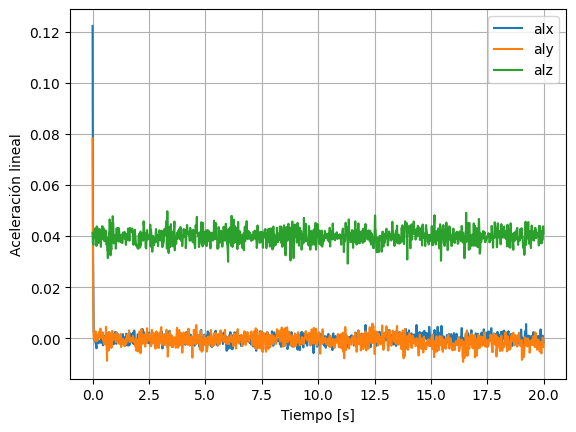

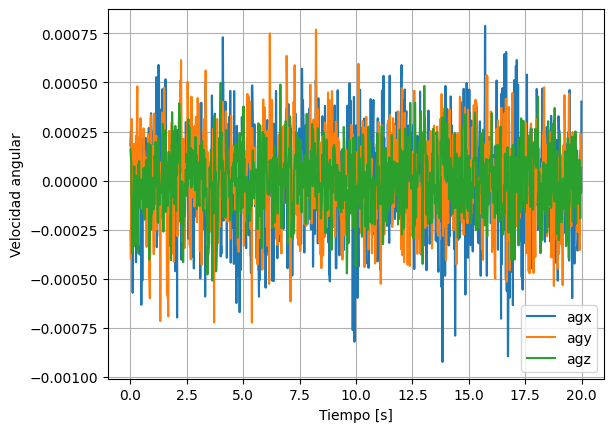

In [103]:
import matplotlib.pyplot as plt

df_init = df_merge[df_merge["timestamp"] <= 20.0]

plt.figure()
plt.plot(df_init["timestamp"], df_init["alx"], label="alx")
plt.plot(df_init["timestamp"], df_init["aly"], label="aly")
plt.plot(df_init["timestamp"], df_init["alz"], label="alz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración lineal")
plt.grid()
plt.legend()
plt.show()

plt.figure()
plt.plot(df_init["timestamp"], df_init["agx"], label="agx")
plt.plot(df_init["timestamp"], df_init["agy"], label="agy")
plt.plot(df_init["timestamp"], df_init["agz"], label="agz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad angular")
plt.grid()
plt.legend()
plt.show()

In [104]:
gn = init_values["gn"]
g0 = init_values["g0"]
acc_bias = init_values["acc_bias"]
gyro_bias = init_values["gyro_bias"]
gyro_noise = init_values["gyro_noise"]
acc_noise = init_values["acc_noise"]
q0_mean = init_values["q0_mean"]
biases = {
    "alx": acc_bias[0],
    "aly": acc_bias[1],
    "alz": acc_bias[2],
    "agx": gyro_bias[0],
    "agy": gyro_bias[1],
    "agz": gyro_bias[2],
}

biases

{'alx': np.float64(-0.0002629126394052044),
 'aly': np.float64(-0.0008737304832713754),
 'alz': np.float64(0.03992969454770756),
 'agx': np.float64(-1.2472118959107808e-05),
 'agy': np.float64(1.798017348203223e-06),
 'agz': np.float64(1.0371747211895906e-06)}

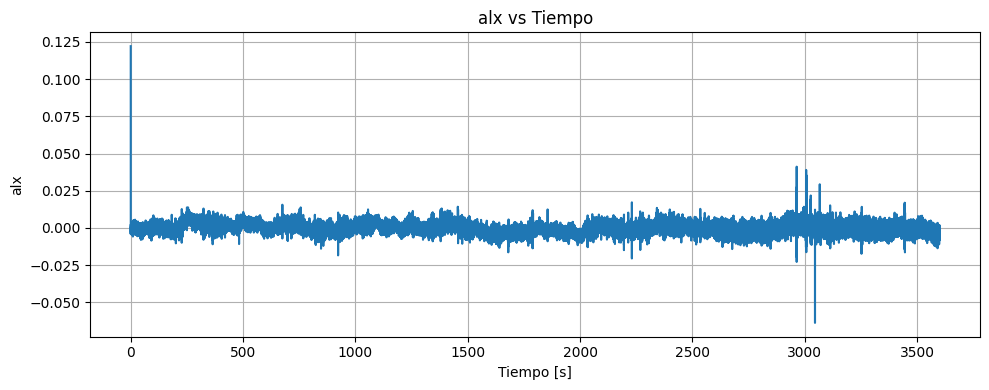

alx


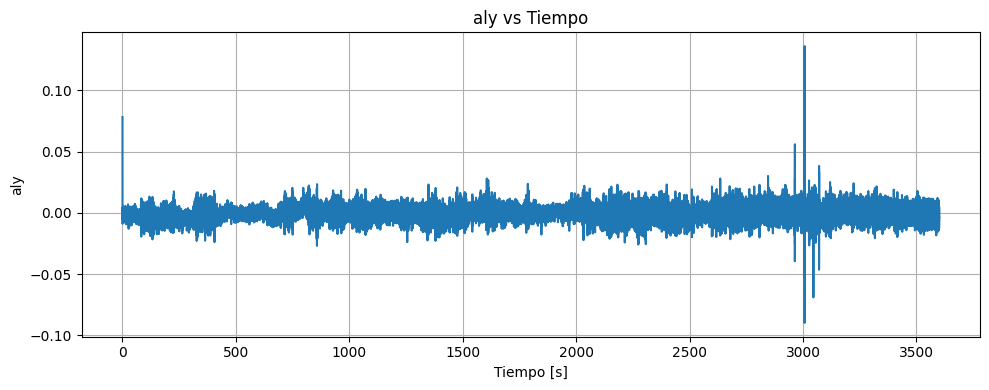

aly


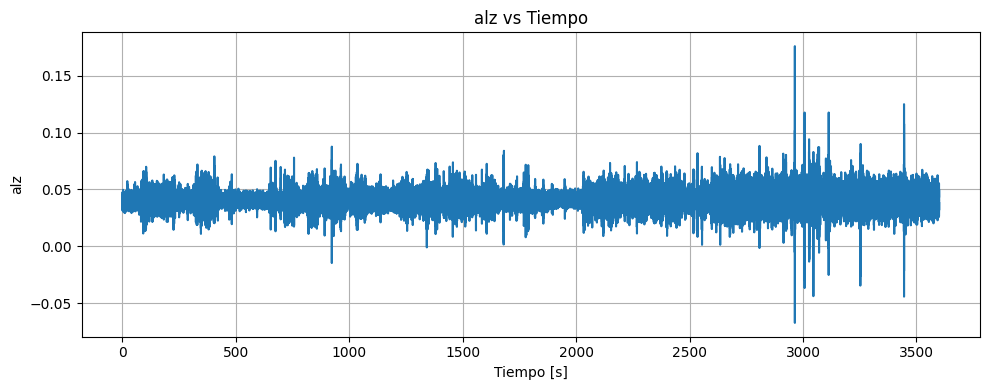

alz


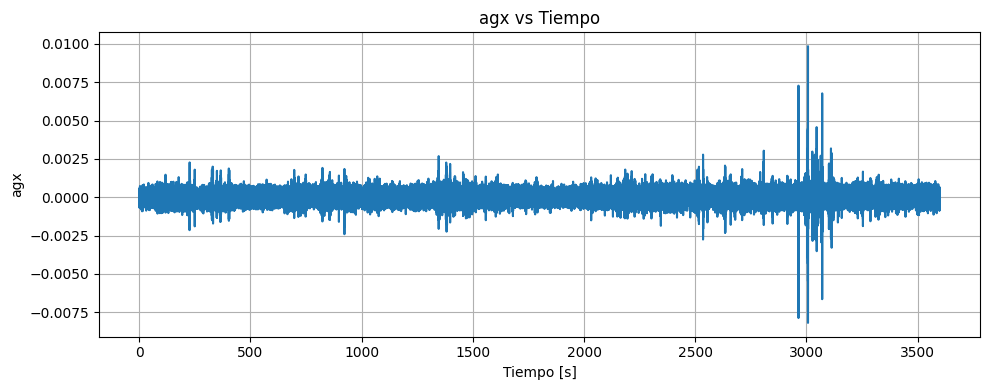

agx


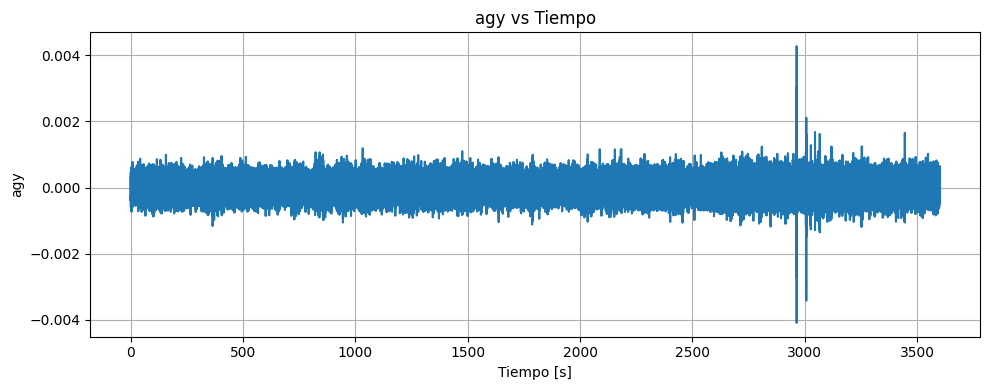

agy


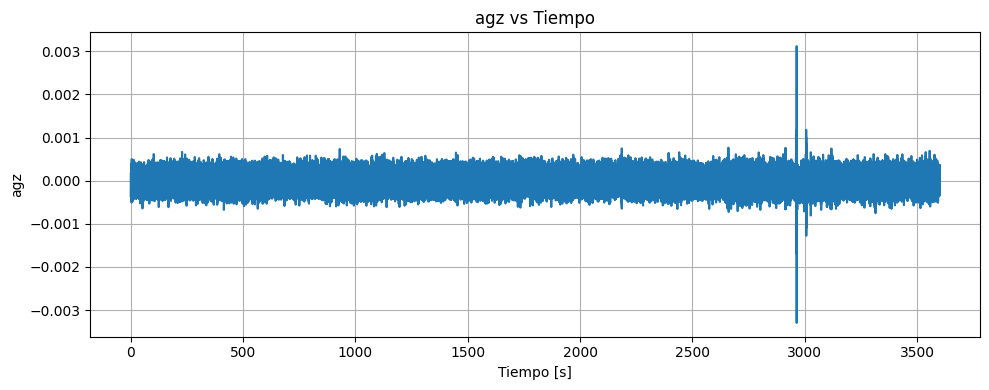

agz


In [105]:
# sigma = 0.01 # desviación estandar

# rudio_gyro = np.random.normal(loc=0, scale=sigma, size=n)

# # plt.plot(np.arange(n) * dt, rudio_gyro)
# plt.xlabel("Tiempo [s]")
# # plt.ylabel("Ruido del giroscopio [deg/s]")
# # plt.title("Ruido blanco en velocidad angular")
# # plt.grid()
# # plt.show()

# print(df.columns[3])
def plot_data_vs_time(df, col):
    df = df.copy()

    # Convertir Time a numérico
    df["Time"] = pd.to_numeric(df["Time"], errors="coerce")

    # Eliminar filas donde Time no pudo convertirse
    # df = df.dropna(subset=["Time"])

    # Tiempo relativo en segundos
    t = (df["Time"] - df["Time"].iloc[0]) / 1e9

    # print(t)

    # for col in df.columns:
    #     if col == "Time":
    #         continue

    # print(df[col])

    # Convertir también la columna actual a numérico por seguridad
    y = pd.to_numeric(df[col], errors="coerce")

    plt.figure(figsize=(10, 4))
    plt.plot(t, y)
    plt.xlabel("Tiempo [s]")
    plt.ylabel(col)
    plt.title(f"{col} vs Tiempo")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
        
# plot_data_vs_time(df=df, col="scaledAccelY")

for column in df_merge.columns[1:7]:
    plot_data_vs_time(df=df_merge, col=column)
    print(column)


In [106]:
df_merge.columns[:]

Index(['Time', 'alx', 'aly', 'alz', 'agx', 'agy', 'agz', 'q0', 'q1', 'q2',
       'q3', 'timestamp', 'dt', 'al_norm', 'ag_norm'],
      dtype='str')

In [107]:
# Etapa de filtrado

alx = df_merge['alx'].values
aly = df_merge['aly'].values
alz = df_merge['alz'].values
agx = df_merge['agx'].values
agy = df_merge['agy'].values
agz = df_merge['agz'].values

ang_acc = np.vstack((alx, aly, alz, agx, agy, agz)).T

ang_acc

array([[ 1.22194e-01,  7.82580e-02,  4.13050e-02,  1.78000e-04,
        -2.60000e-04,  1.60000e-04],
       [ 3.67770e-02,  2.25420e-02,  3.72600e-02,  2.56000e-04,
        -4.00000e-04,  1.18000e-04],
       [ 1.04460e-02,  5.42200e-03,  3.66280e-02,  2.54000e-04,
         1.10000e-05,  9.40000e-05],
       ...,
       [-2.73300e-03, -1.67600e-03,  4.19290e-02,  5.06000e-04,
         6.52000e-04,  1.94000e-04],
       [-2.73300e-03, -1.67600e-03,  4.19290e-02,  5.06000e-04,
         6.52000e-04,  1.94000e-04],
       [-2.44000e-03, -3.12600e-03,  4.38660e-02,  8.70000e-05,
         1.15000e-04,  3.61000e-04]], shape=(293753, 6))

In [108]:
from scipy.signal import butter, filtfilt

def butter_lowpass(fc, fs, order=4):
    wn = fc / (fs / 2)
    b, a = butter(order, wn, btype='low')
    return b, a

fs = 100.0      # Hz
fc = 10  # Hz
b, a = butter_lowpass(fc, fs, order=4)

alx_f = filtfilt(b, a, alx)
aly_f = filtfilt(b, a, aly)
alz_f = filtfilt(b, a, alz)
agx_f = filtfilt(b, a, agx)
agy_f = filtfilt(b, a, agy)
agz_f = filtfilt(b, a, agz)
alx_f

array([ 0.12219178,  0.0779535 ,  0.03958427, ..., -0.00246016,
       -0.00242857, -0.00243055], shape=(293753,))

In [109]:
df_merge['alx_f'] = alx_f
df_merge['aly_f'] = aly_f
df_merge['alz_f'] = alz_f
df_merge['agx_f'] = agx_f
df_merge['agy_f'] = agy_f
df_merge['agz_f'] = agz_f
df_merge.columns[:]

Index(['Time', 'alx', 'aly', 'alz', 'agx', 'agy', 'agz', 'q0', 'q1', 'q2',
       'q3', 'timestamp', 'dt', 'al_norm', 'ag_norm', 'alx_f', 'aly_f',
       'alz_f', 'agx_f', 'agy_f', 'agz_f'],
      dtype='str')

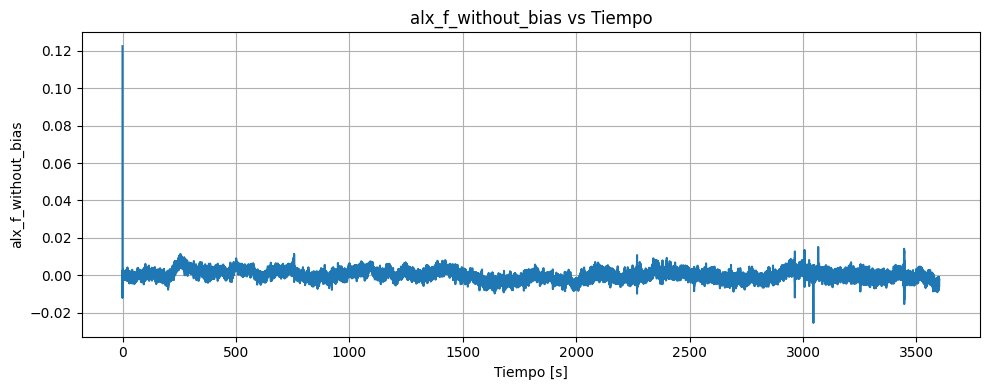

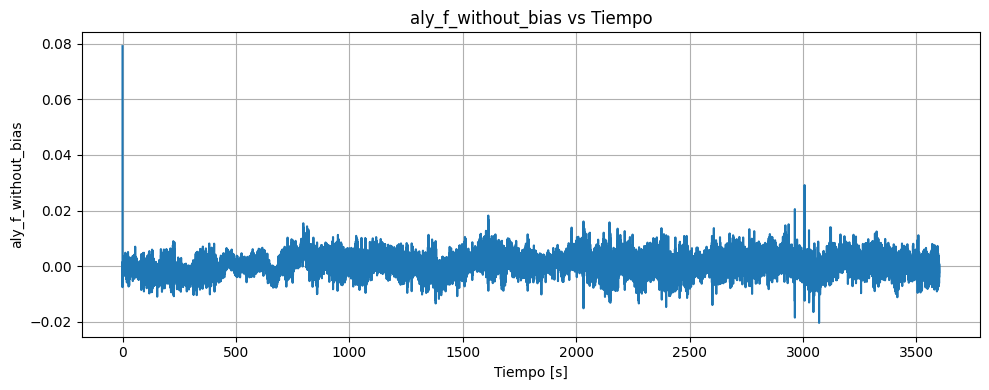

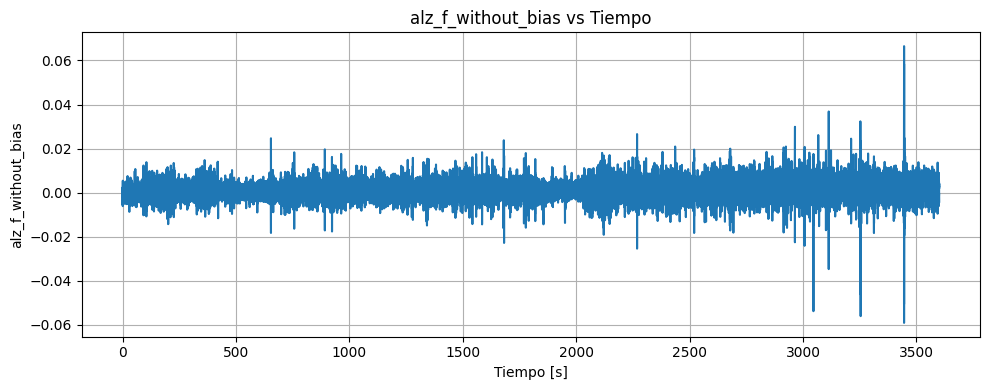

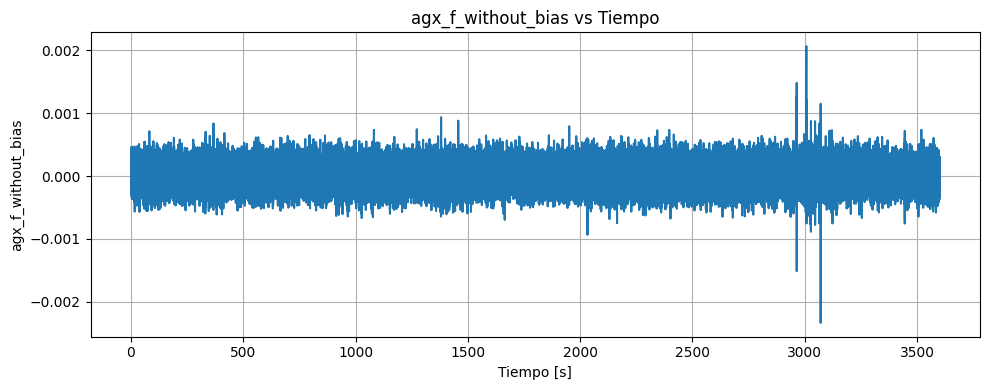

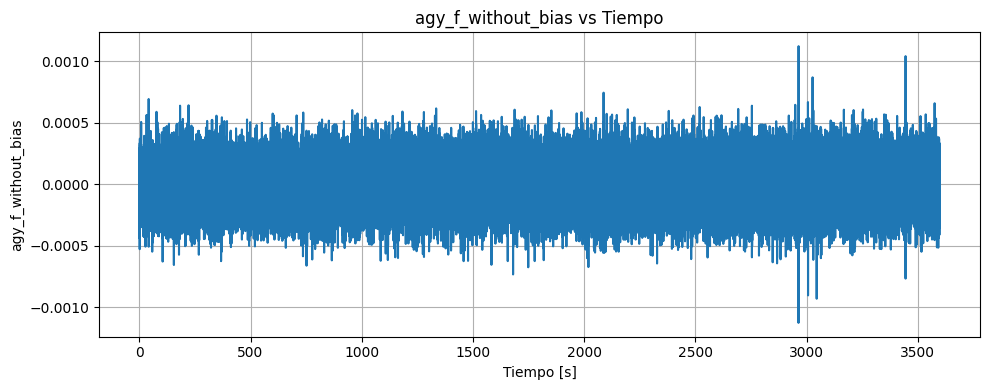

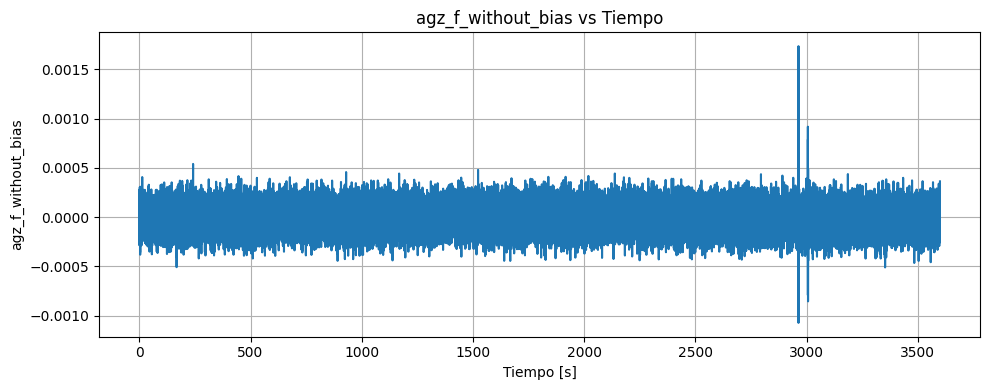

In [110]:
def data_without_bias(df, col_input, col_output):
    # print(df)
    # df[col_output] = df[col_input] - mean(df, col_input)
    # print(df[col_input])
    # print(biases[col_input])
    df[col_output] = df[col_input+"_f"] - biases[col_input]
    # print(biases)
    # Tiempo relativo en segundos
    t = (df["Time"] - df["Time"].iloc[0]) / 1e9

    # for col in df.columns:
    #     if col == "Time":
    #         continue

    # Convertir también la columna actual a numérico por seguridad
    y = pd.to_numeric(df[col_output], errors="coerce")

    plt.figure(figsize=(10, 4))
    plt.plot(t, y)
    plt.xlabel("Tiempo [s]")
    plt.ylabel(col_output)
    plt.title(f"{col_output} vs Tiempo")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for column in df_merge.columns[1:7]:
    data_without_bias(df=df_merge, col_input=column, col_output=column+"_f"+"_without_bias")
    # print(column+"_without_bias", " u:", biases[column], " o2:", var[column]," o:", std[column])

# print(df_merge.columns[13:19])

In [111]:
print(df_merge.columns[:])

Index(['Time', 'alx', 'aly', 'alz', 'agx', 'agy', 'agz', 'q0', 'q1', 'q2',
       'q3', 'timestamp', 'dt', 'al_norm', 'ag_norm', 'alx_f', 'aly_f',
       'alz_f', 'agx_f', 'agy_f', 'agz_f', 'alx_f_without_bias',
       'aly_f_without_bias', 'alz_f_without_bias', 'agx_f_without_bias',
       'agy_f_without_bias', 'agz_f_without_bias'],
      dtype='str')


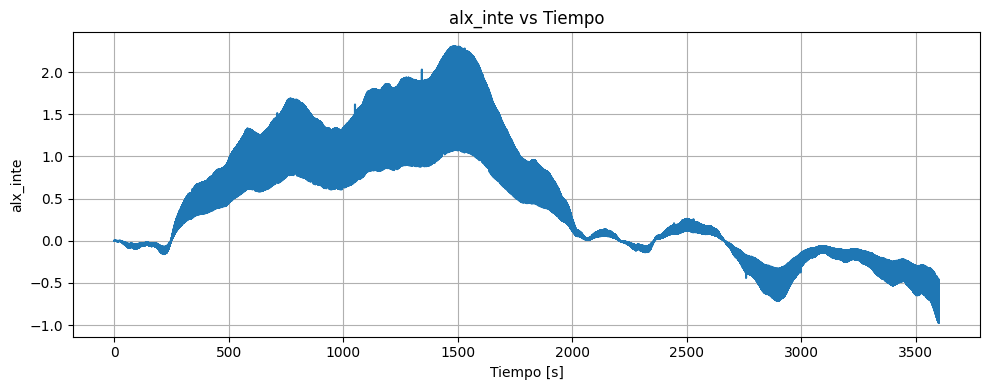

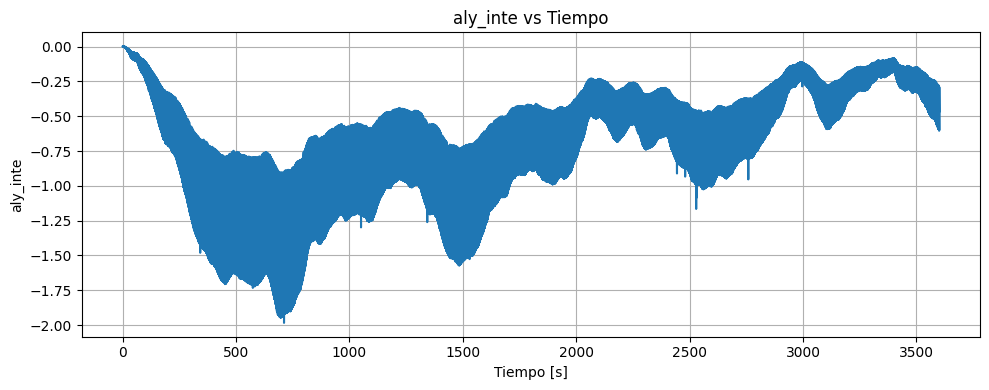

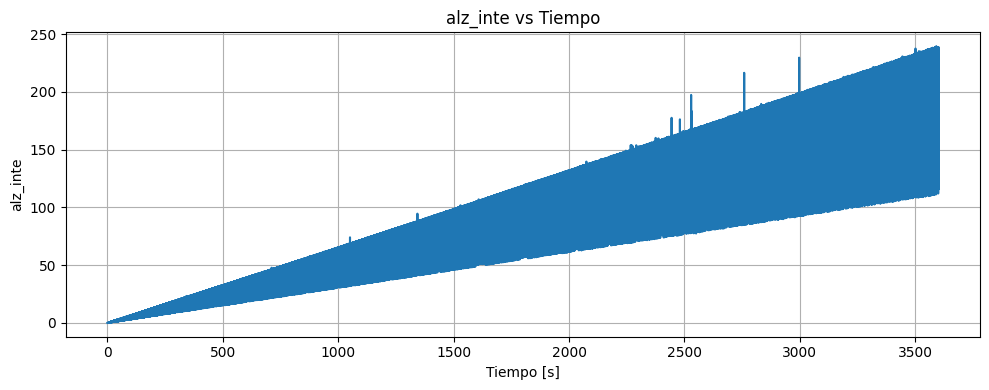

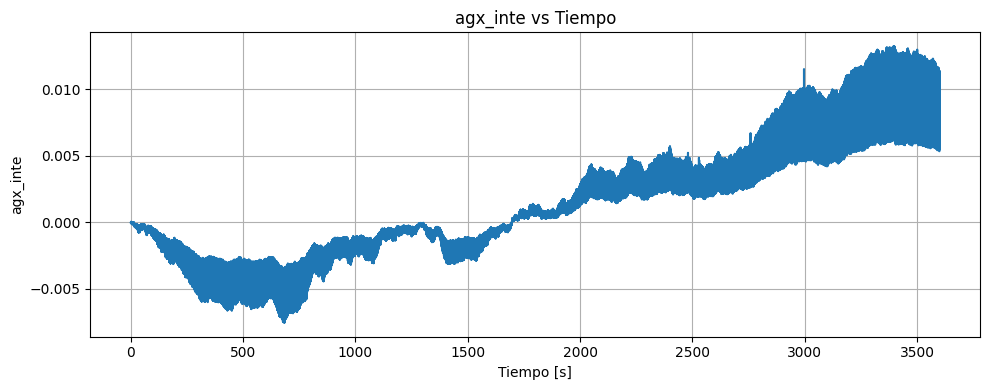

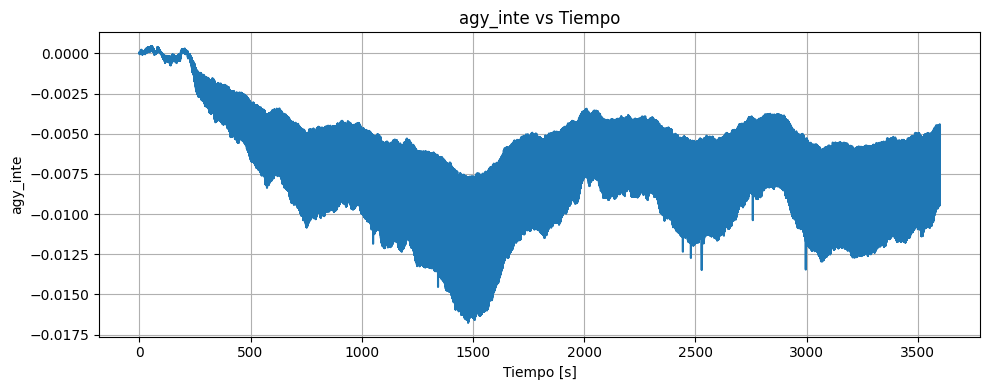

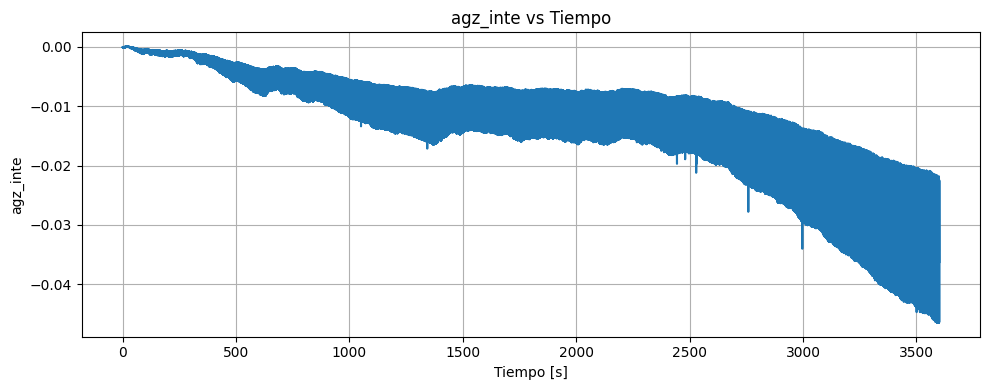

In [112]:
def plot_integ_data_vs_time(df, col_input):#, col_output):
    # df = df.copy()

    y = np.cumsum(df[col_input]) * dt

    t = (df["Time"] - df["Time"].iloc[0]) / 1e9

    # y = df[col_output]

    plt.figure(figsize=(10, 4))
    plt.plot(t, y)
    plt.xlabel("Tiempo [s]")
    plt.ylabel(col_input+'_inte')
    plt.title(f"{col_input+'_inte'} vs Tiempo")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

for column in df_merge.columns[1:7]:
    plot_integ_data_vs_time(df=df_merge, col_input=column)#col_output=column+"_inte")
    # print(column+"_inte", " u:", mean(df,column+"_inte"), " o2:", variance(df,column+"_inte")," o:", standard_deviation(df,column+"_inte"))
    # print(column+"_inte", " u:", mean(df, column), " o2:", variance(df, column)," o:", standard_deviation(df, column))

# for column in df.columns[1:]:
#     print(column, " u:", mean(df,column), " o2:", variance(df,column)," o:", standard_deviation(df,column))

    

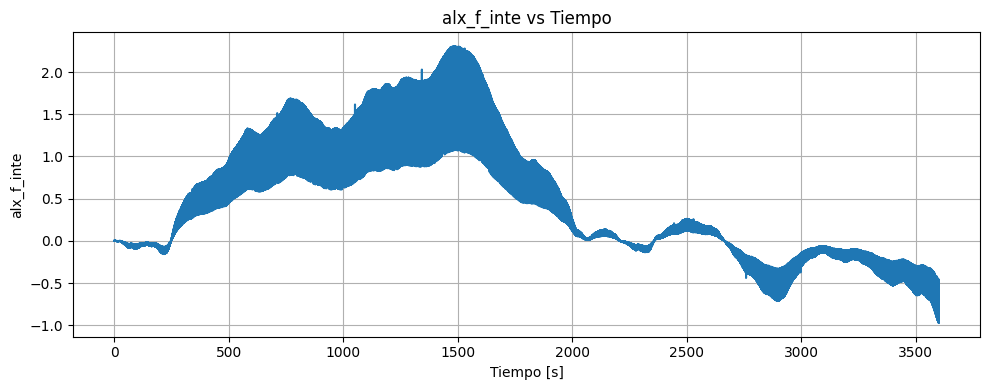

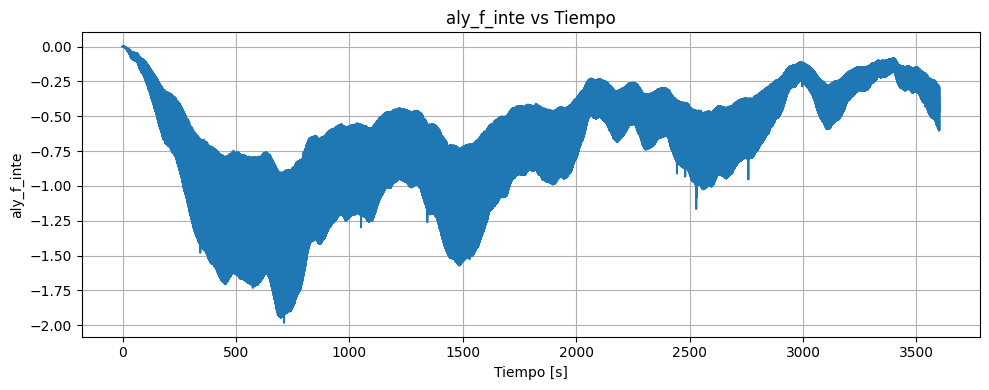

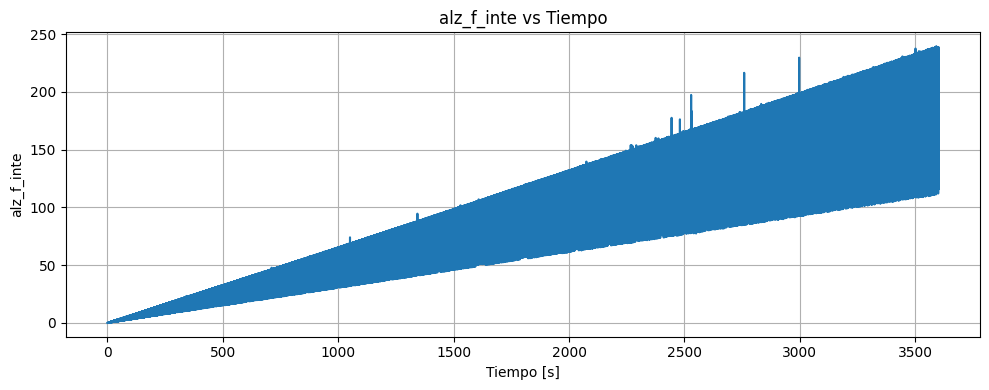

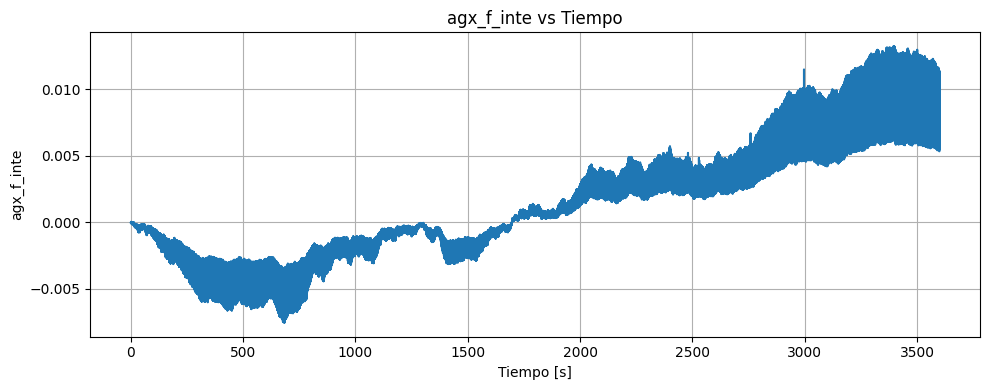

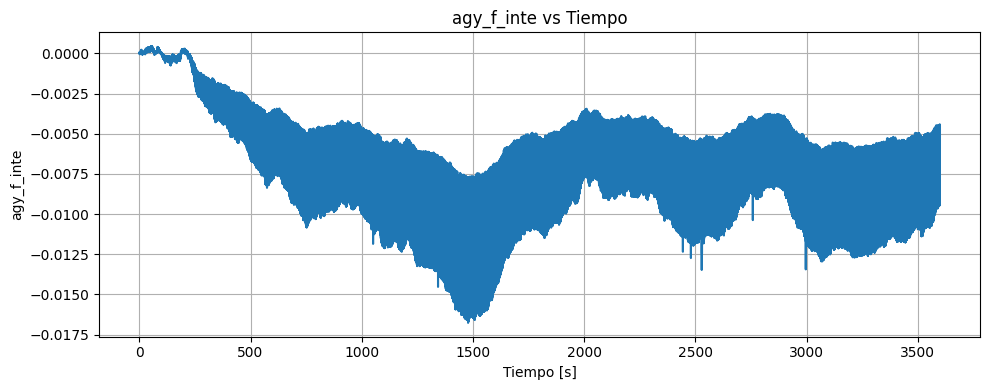

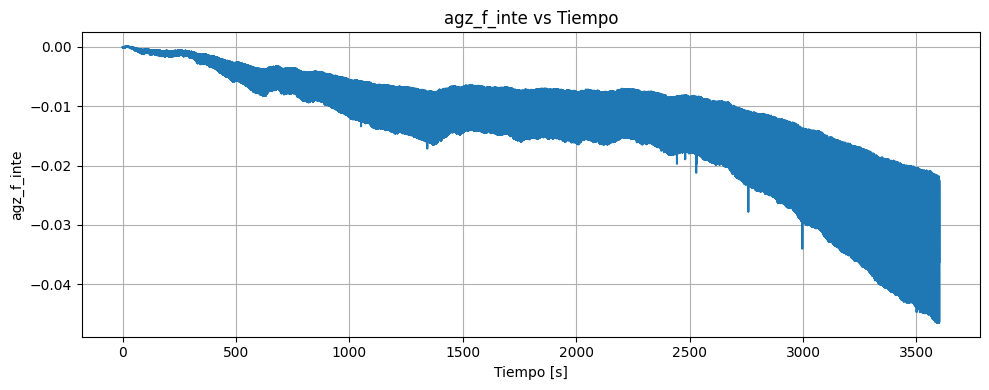

In [113]:
for column in df_merge.columns[15:21]:
    plot_integ_data_vs_time(df=df_merge, col_input=column)

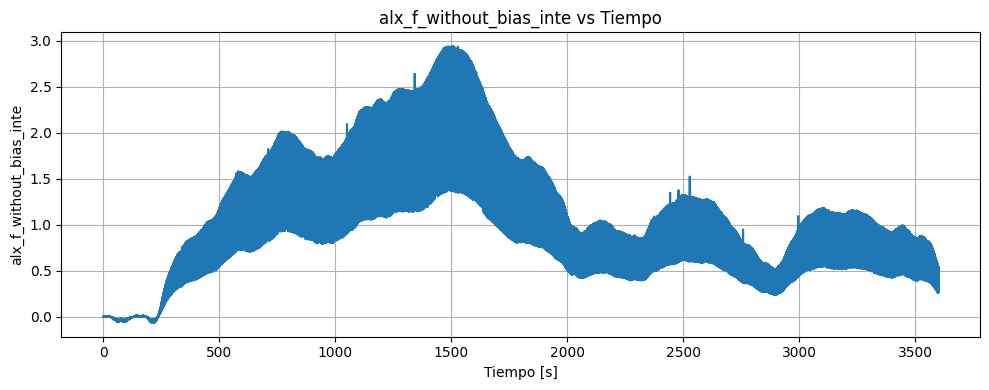

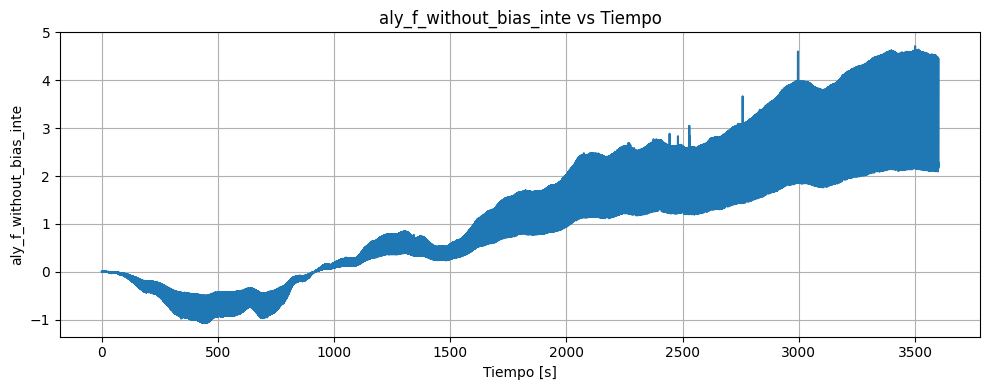

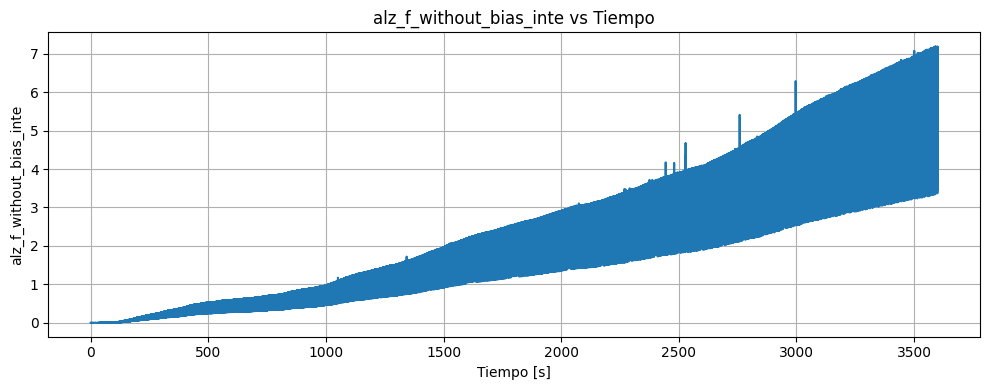

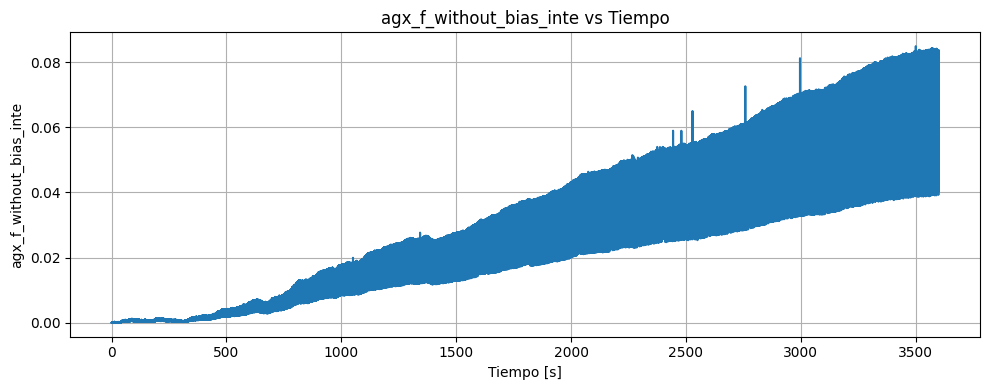

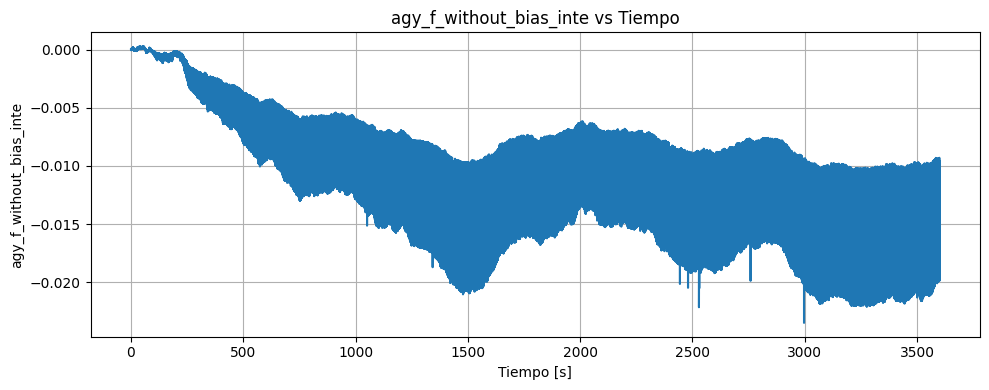

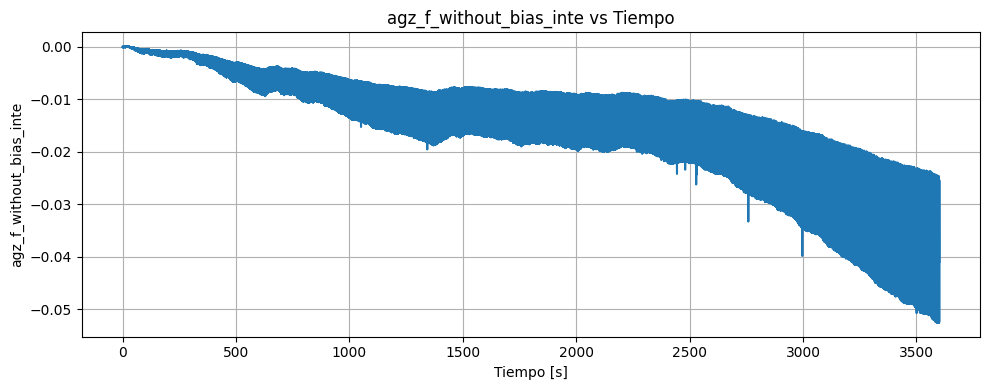

In [114]:
for column in df_merge.columns[21:28]:
    plot_integ_data_vs_time(df=df_merge, col_input=column)

In [115]:
df_merge

,Time,alx,aly,alz,agx,agy,agz,q0,q1,q2,...,alz_f,agx_f,agy_f,agz_f,alx_f_without_bias,aly_f_without_bias,alz_f_without_bias,agx_f_without_bias,agy_f_without_bias,agz_f_without_bias
0,1776867651109628141,0.122194,0.078258,0.041305,0.000178,-0.000260,0.000160,0.999960,-0.004786,0.007499,...,0.041322,0.000180,-0.000259,0.000160,0.122455,0.079125,0.001392,0.000193,-0.000261,0.000159
1,1776867651129055331,0.036777,0.022542,0.037260,0.000256,-0.000400,0.000118,0.999960,-0.004783,0.007495,...,0.040614,0.000184,-0.000105,0.000073,0.078216,0.050231,0.000685,0.000197,-0.000106,0.000072
2,1776867651148775540,0.010446,0.005422,0.036628,0.000254,0.000011,0.000094,0.999960,-0.004781,0.007497,...,0.040096,0.000173,0.000028,-0.000015,0.039847,0.025252,0.000167,0.000185,0.000026,-0.000016
3,1776867651158459255,0.002468,0.000072,0.041189,0.000149,0.000314,-0.000076,0.999961,-0.004752,0.007509,...,0.039881,0.000136,0.000121,-0.000102,0.011495,0.006958,-0.000049,0.000149,0.000119,-0.000103
4,1776867651168547547,0.002468,0.000072,0.041189,0.000149,0.000314,-0.000076,0.999961,-0.004752,0.007509,...,0.039963,0.000074,0.000167,-0.000181,-0.005409,-0.003700,0.000033,0.000087,0.000165,-0.000182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293748,1776871251058017354,-0.002777,-0.001648,0.036820,0.000170,-0.000283,-0.000184,0.999852,-0.004761,0.007711,...,0.041896,0.000075,0.000138,0.000060,-0.002401,0.000597,0.001966,0.000087,0.000136,0.000059
293749,1776871251077746367,-0.003580,0.004960,0.047645,0.000268,-0.000126,-0.000146,0.999852,-0.004759,0.007711,...,0.042167,0.000162,0.000161,0.000083,-0.002275,0.000693,0.002237,0.000175,0.000159,0.000081
293750,1776871251087383122,-0.002733,-0.001676,0.041929,0.000506,0.000652,0.000194,0.999852,-0.004753,0.007719,...,0.042635,0.000191,0.000165,0.000145,-0.002197,0.000174,0.002705,0.000203,0.000163,0.000144
293751,1776871251097535211,-0.002733,-0.001676,0.041929,0.000506,0.000652,0.000194,0.999852,-0.004753,0.007719,...,0.043251,0.000158,0.000149,0.000243,-0.002166,-0.000871,0.003321,0.000170,0.000148,0.000242


In [116]:

def normalized(x):
    x = np.asarray(x, dtype=float)
    n = np.linalg.norm(x)
    if n < 1e-12:
        return x
    return x / n

def I(n):
    '''
    unit matrix
    just making its name prettier than np.eye
    '''
    return np.eye(n)

def skew(x):
    '''
    takes in a 3d column vector
    returns its Skew-symmetric matrix
    '''

    x = x.T[0]
    return np.array([[0, -x[2], x[1]], [x[2], 0, -x[0]], [-x[1], x[0], 0]])

def rotate(q):
    '''
    rotation transformation matrix
    nav frame to body frame as q is expected to be q^nb
    R(q) @ x to rotate x
    '''

    qv = q[1:4, :]
    qc = q[0]
    return (qc**2 - qv.T @ qv) * I(3) - 2 * qc * skew(qv) + 2 * qv @ qv.T


In [117]:
import numpy as np

def compute_navigation_acceleration(
    df,
    # init,
    accel_cols=("alx_f_without_bias", "aly_f_without_bias", "alz_f_without_bias"),
    quat_cols=("q0", "q1", "q2", "q3")
):
    """
    Calcula aceleración en marco navegación usando aceleración lineal del IMU
    y cuaternión.

    Parámetros
    ----------
    df : pandas.DataFrame
        DataFrame con aceleraciones y cuaterniones.

    init : dict
        Diccionario devuelto por initialize_from_dataframe(...).
        Debe contener init["gn"].

    accel_cols : tuple
        Columnas de aceleración en body/frame IMU.
        Ejemplo:
            ("alx", "aly", "alz")
            ("alx_f", "aly_f", "alz_f")
            ("alx_f_without_bias", "aly_f_without_bias", "alz_f_without_bias")

    quat_cols : tuple
        Columnas de cuaternión.
        Por defecto: ("q0", "q1", "q2", "q3")

    Retorna
    -------
    df_out, orix, oriy, oriz
    """

    # gn = np.asarray(init["gn"], dtype=float).reshape(3, 1)

    required_cols = list(accel_cols) + list(quat_cols)
    missing = [c for c in required_cols if c not in df.columns]

    if missing:
        raise ValueError(f"Faltan columnas en el DataFrame: {missing}")

    df_out = df.copy()

    a_nav = []
    orix = []
    oriy = []
    oriz = []

    init_ori = I(3)

    conj = -I(4)
    conj[0, 0] = 1

    for _, row in df_out.iterrows():

        at = np.array([
            [row[accel_cols[0]]],
            [row[accel_cols[1]]],
            [row[accel_cols[2]]]
        ], dtype=float)

        q = np.array([
            [row[quat_cols[0]]],
            [row[quat_cols[1]]],
            [row[quat_cols[2]]],
            [row[quat_cols[3]]]
        ], dtype=float)

        q = normalized(q)

        R_nb = rotate(conj @ q)

        an = R_nb @ at # + gn
        orin = R_nb @ init_ori

        a_nav.append(an.ravel())
        orix.append(orin[0, :])
        oriy.append(orin[1, :])
        oriz.append(orin[2, :])

    a_nav = np.array(a_nav)
    orix = np.array(orix)
    oriy = np.array(oriy)
    oriz = np.array(oriz)

    df_out["anx"] = a_nav[:, 0]
    df_out["any"] = a_nav[:, 1]
    df_out["anz"] = a_nav[:, 2]

    return df_out, orix, oriy, oriz

In [118]:
df_nav, orix, oriy, oriz = compute_navigation_acceleration(
    df_merge,
    accel_cols=("alx_f_without_bias", "aly_f_without_bias", "alz_f_without_bias")
)

In [119]:
df_nav.head()

,Time,alx,aly,alz,agx,agy,agz,q0,q1,q2,...,agz_f,alx_f_without_bias,aly_f_without_bias,alz_f_without_bias,agx_f_without_bias,agy_f_without_bias,agz_f_without_bias,anx,any,anz
0,1776867651109628141,0.122194,0.078258,0.041305,0.000178,-0.000260,0.000160,0.999960,-0.004786,0.007499,...,0.000160,0.122455,0.079125,0.001392,0.000193,-0.000261,0.000159,0.122450,0.079135,-0.001202
1,1776867651129055331,0.036777,0.022542,0.037260,0.000256,-0.000400,0.000118,0.999960,-0.004783,0.007495,...,0.000073,0.078216,0.050231,0.000685,0.000197,-0.000106,0.000072,0.078211,0.050235,-0.000968
2,1776867651148775540,0.010446,0.005422,0.036628,0.000254,0.000011,0.000094,0.999960,-0.004781,0.007497,...,-0.000015,0.039847,0.025252,0.000167,0.000185,0.000026,-0.000016,0.039842,0.025253,-0.000672
3,1776867651158459255,0.002468,0.000072,0.041189,0.000149,0.000314,-0.000076,0.999961,-0.004752,0.007509,...,-0.000102,0.011495,0.006958,-0.000049,0.000149,0.000119,-0.000103,0.011492,0.006958,-0.000287
4,1776867651168547547,0.002468,0.000072,0.041189,0.000149,0.000314,-0.000076,0.999961,-0.004752,0.007509,...,-0.000181,-0.005409,-0.003700,0.000033,0.000087,0.000165,-0.000182,-0.005408,-0.003699,0.000149


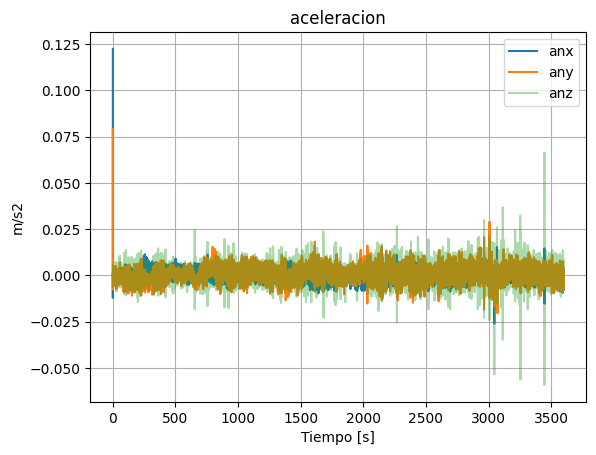

In [120]:
plt.figure()
plt.plot(t, df_nav["anx"], label="anx")
plt.plot(t, df_nav["any"], label="any")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_nav["anz"], label="anz", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("m/s2")
plt.legend()
plt.grid(True)
plt.title("aceleracion")
plt.show()

In [121]:
import numpy as np

def zupt_df(df, dt=0.005, threshold=0.02):
    """
    Aplica ZUPT usando aceleración en navegación desde un DataFrame.

    Requiere columnas:
        anx, any, anz

    Agrega columnas:
        vnx, vny, vnz
        zupt_flag
    """

    df = df.copy()

    # Pasar aceleración navegación a array Nx3
    a_nav = df[["anx", "any", "anz"]].to_numpy(dtype=float)

    sample_number = a_nav.shape[0]

    velocities = []
    zupt_flags = []

    prevt = -1
    still_phase = False

    v = np.zeros((3, 1))

    for t in range(sample_number):

        at = a_nav[t].reshape(3, 1)

        if np.linalg.norm(at) < threshold:
            zupt_flags.append(1)

            if not still_phase:
                predict_v = v + at * dt

                denom = t - prevt

                if denom > 0:
                    v_drift_rate = predict_v / denom

                    for i in range(t - prevt - 1):
                        velocities[prevt + 1 + i] -= (i + 1) * v_drift_rate.T[0]

            v = np.zeros((3, 1))
            prevt = t
            still_phase = True

        else:
            zupt_flags.append(0)

            v = v + at * dt
            still_phase = False

        velocities.append(v.T[0])

    velocities = np.array(velocities)

    df["vnx"] = velocities[:, 0]
    df["vny"] = velocities[:, 1]
    df["vnz"] = velocities[:, 2]

    df["zupt_flag"] = zupt_flags

    return df

In [122]:
df_zupt = zupt_df(
    df_nav,
    dt=0.01,
    threshold=0.02
)

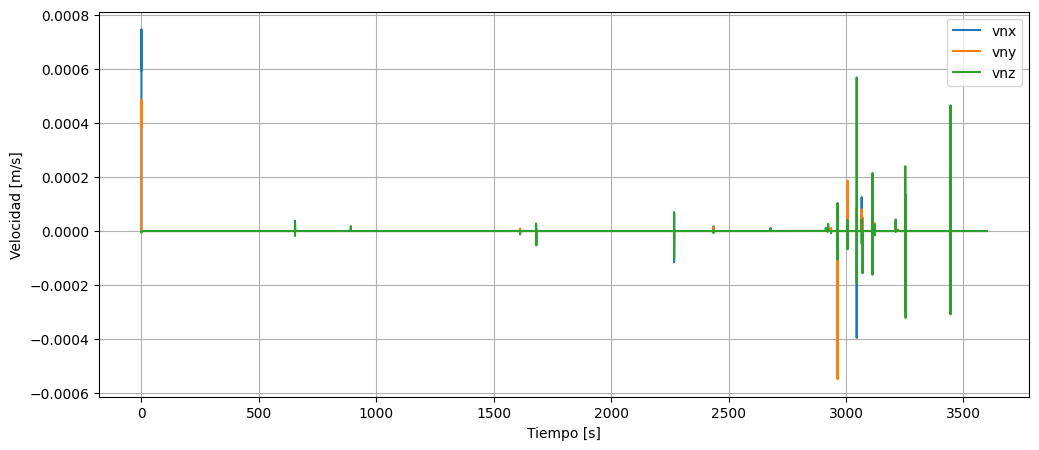

In [123]:
import matplotlib.pyplot as plt

t = df_zupt["timestamp"] if "timestamp" in df_zupt.columns else np.arange(len(df_zupt))

plt.figure(figsize=(12, 5))
plt.plot(t, df_zupt["vnx"], label="vnx")
plt.plot(t, df_zupt["vny"], label="vny")
plt.plot(t, df_zupt["vnz"], label="vnz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad [m/s]")
plt.grid()
plt.legend()
plt.show()

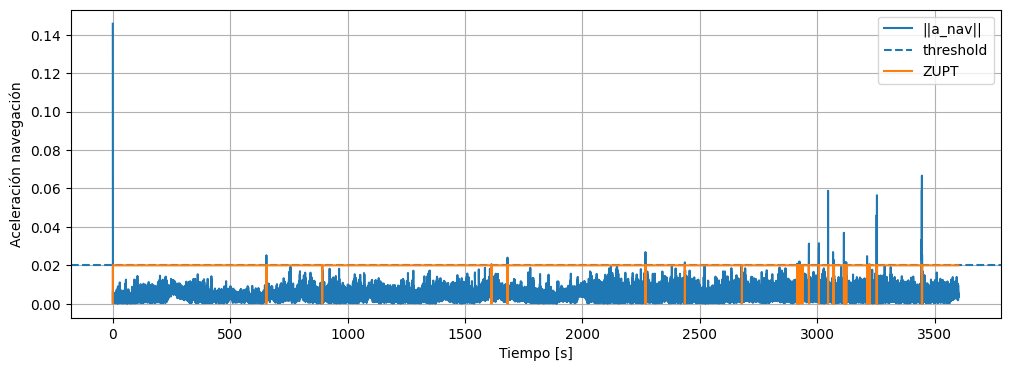

In [124]:
a_norm = np.linalg.norm(df_zupt[["anx", "any", "anz"]].to_numpy(), axis=1)

plt.figure(figsize=(12, 4))
plt.plot(t, a_norm, label="||a_nav||")
plt.axhline(0.02, linestyle="--", label="threshold")
plt.plot(t, df_zupt["zupt_flag"] * 0.02, label="ZUPT")
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración navegación")
plt.grid()
plt.legend()
plt.show()

In [ ]:
import numpy as np

def position_df(df, dt=0.01, use_dt_col=True):
    """
    Integra posición usando velocidad ZUPT.

    Requiere:
        vnx, vny, vnz

    Opcional:
        dt

    Agrega:
        px, py, pz, pnorm
    """

    df = df.copy()

    velocities = df[["vnx", "vny", "vnz"]].to_numpy(dtype=float)

    positions = []
    p = np.zeros((3, 1))

    for t in range(len(df)):

        vt = velocities[t].reshape(3, 1)

        if use_dt_col and "dt" in df.columns:
            dtk = float(df["dt"].iloc[t])

            if not np.isfinite(dtk) or dtk <= 0:
                dtk = dt
        else:
            dtk = dt

        p = p + vt * dtk

        positions.append(p.T[0])

    positions = np.array(positions)

    df["px"] = positions[:, 0]
    df["py"] = positions[:, 1]
    df["pz"] = positions[:, 2]

    df["pnorm"] = np.linalg.norm(positions, axis=1)

    return df

In [ ]:
df_pos = position_df(df_zupt, dt=0.01)

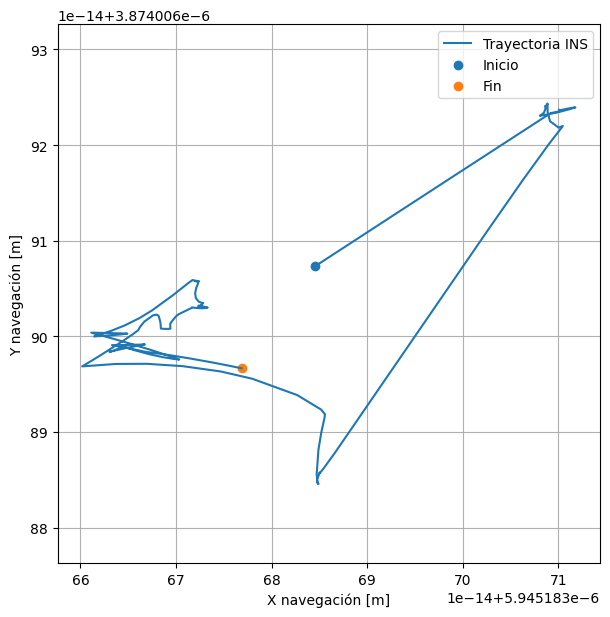

In [127]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.plot(df_pos["px"], df_pos["py"], label="Trayectoria INS")
plt.scatter(df_pos["px"].iloc[0], df_pos["py"].iloc[0], label="Inicio")
plt.scatter(df_pos["px"].iloc[-1], df_pos["py"].iloc[-1], label="Fin")
plt.xlabel("X navegación [m]")
plt.ylabel("Y navegación [m]")
plt.axis("equal")
plt.grid()
plt.legend()
plt.show()

In [128]:
import numpy as np

def nhc_df(df, K_nhc_y=1.0, K_nhc_z=1.0):
    """
    Aplica Non-Holonomic Constraint a la velocidad.

    Requiere columnas:
        vnx, vny, vnz
        q0, q1, q2, q3

    Agrega columnas:
        vbx_raw, vby_raw, vbz_raw
        vbx_nhc, vby_nhc, vbz_nhc
        vnx_nhc, vny_nhc, vnz_nhc
    """

    df = df.copy()

    required_cols = ["vnx", "vny", "vnz", "q0", "q1", "q2", "q3"]
    missing = [c for c in required_cols if c not in df.columns]

    if missing:
        raise ValueError(f"Faltan columnas en el DataFrame: {missing}")

    conj = -I(4)
    conj[0, 0] = 1

    v_body_raw_list = []
    v_body_nhc_list = []
    v_nav_nhc_list = []

    for _, row in df.iterrows():

        # Velocidad en navegación
        v_nav = np.array([
            [row["vnx"]],
            [row["vny"]],
            [row["vnz"]]
        ], dtype=float)

        # Cuaternión q = [q0, q1, q2, q3]
        q = np.array([
            [row["q0"]],
            [row["q1"]],
            [row["q2"]],
            [row["q3"]]
        ], dtype=float)

        q = normalized(q)

        # Según tu convención:
        # rotate(conj @ q) = body -> nav
        # rotate(q)        = nav -> body
        v_body = rotate(q) @ v_nav

        vx_b = v_body[0, 0]
        vy_b = v_body[1, 0]
        vz_b = v_body[2, 0]

        # Aplicar NHC:
        # El vehículo no debería tener velocidad lateral ni vertical en body.
        vy_b_corr = vy_b * (1.0 - K_nhc_y)
        vz_b_corr = vz_b * (1.0 - K_nhc_z)

        v_body_corr = np.array([
            [vx_b],
            [vy_b_corr],
            [vz_b_corr]
        ], dtype=float)

        # Volver de body -> navegación
        v_nav_corr = rotate(conj @ q) @ v_body_corr

        v_body_raw_list.append(v_body.T[0])
        v_body_nhc_list.append(v_body_corr.T[0])
        v_nav_nhc_list.append(v_nav_corr.T[0])

    v_body_raw = np.array(v_body_raw_list)
    v_body_nhc = np.array(v_body_nhc_list)
    v_nav_nhc = np.array(v_nav_nhc_list)

    df["vbx_raw"] = v_body_raw[:, 0]
    df["vby_raw"] = v_body_raw[:, 1]
    df["vbz_raw"] = v_body_raw[:, 2]

    df["vbx_nhc"] = v_body_nhc[:, 0]
    df["vby_nhc"] = v_body_nhc[:, 1]
    df["vbz_nhc"] = v_body_nhc[:, 2]

    df["vnx_nhc"] = v_nav_nhc[:, 0]
    df["vny_nhc"] = v_nav_nhc[:, 1]
    df["vnz_nhc"] = v_nav_nhc[:, 2]

    return df

In [129]:
df_nhc = nhc_df(
    df_zupt,
    K_nhc_y=1.0,
    K_nhc_z=1.0
)

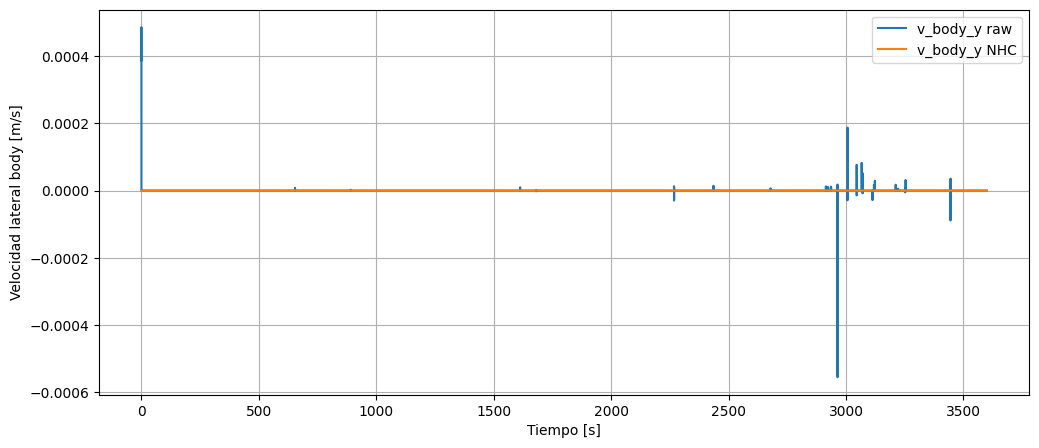

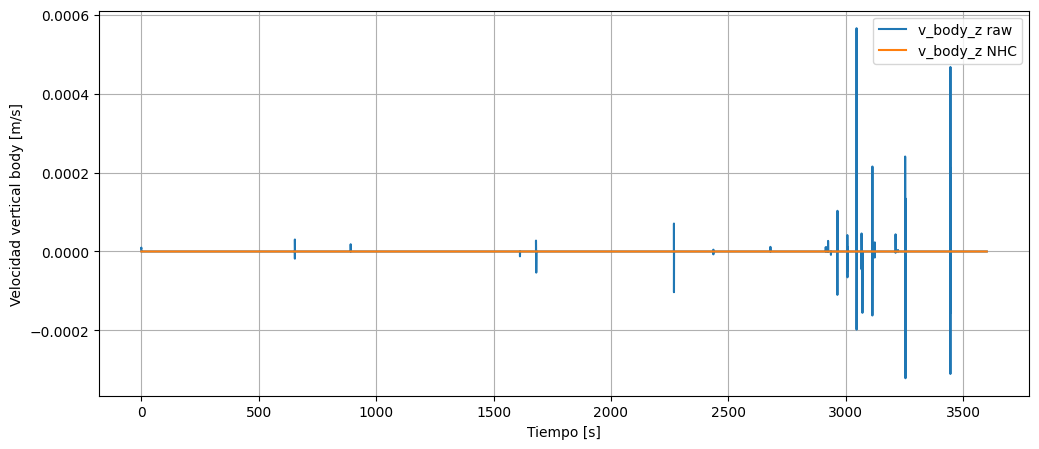

In [130]:
import matplotlib.pyplot as plt

t = df_nhc["timestamp"] if "timestamp" in df_nhc.columns else np.arange(len(df_nhc))

plt.figure(figsize=(12, 5))
plt.plot(t, df_nhc["vby_raw"], label="v_body_y raw")
plt.plot(t, df_nhc["vby_nhc"], label="v_body_y NHC")
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad lateral body [m/s]")
plt.grid()
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(t, df_nhc["vbz_raw"], label="v_body_z raw")
plt.plot(t, df_nhc["vbz_nhc"], label="v_body_z NHC")
plt.xlabel("Tiempo [s]")
plt.ylabel("Velocidad vertical body [m/s]")
plt.grid()
plt.legend()
plt.show()

In [131]:
df_pos = position_df(
    df_nhc,
    dt=0.01,
    vel_cols=("vnx_nhc", "vny_nhc", "vnz_nhc")
)

TypeError: position_df() got an unexpected keyword argument 'vel_cols'